# Tarea 3: Cross-Dataset Ecological Modeling 📊⚕️

**Asignatura:** IELE756 -- Preparación y Análisis de Datos  
**Profesor:** Leo Ferres, PhD  
**Integrantes:** Javier Becerra Muñoz, Jose Pino Muñoz  

## Goal
This is the final and most demanding analytical assignment of the course. You now have three comuna-level summary tables: one from the Census (Tarea 1), one from ENO, and one from GRD (both Tarea 2). Your job is to **link them into a single analytical dataset** and ask whether demographic composition predicts health outcomes at the comuna level.

---

# Part 0: Building the Analytical Table

Your own team has at most three comunas.  Three rows is not a
dataset.  For Tarea 3 we **pool across the class**: every team
published their Tarea 1 and Tarea 2 summary tables as **Quiz 1**,
using a fixed schema and a fixed file-naming convention.  Open
the Canvas group **"IELE756 Tarea 3 data pool"** (via **People**
-> **View User Groups**), go to its **Files** tab, select all
entries, and download them as a single ZIP.  Extract into one
folder (for example, `shared/`).  You should end up with 63 CSVs:
21 census, 21 ENO, 21 GRD.

Concatenate each family into a single master DataFrame (pandas
`concat` over the result of `glob.glob("shared/census_team*.csv")`
is enough).  You should end up with three master tables, one row
per RM comuna.

Run the following sanity checks and report the output in your
notebook:

- Row count per master table, and number of unique
  `codigo_comuna` values.  These should agree; if they do not, you
  have duplicates from overlapping team assignments (investigate).
- Number of comunas that appear in the census master but not in
  ENO or GRD (and vice versa).  Document any asymmetries.
- Locate your own assigned comunas in each master and verify that
  the numbers match the summary tables you produced in Tareas 1
  and 2.  If they do not match, your own Quiz 1 upload was likely
  wrong; state in a Markdown cell what you found and which version
  you are using going forward.

If a classmate's CSV is missing or malformed, ping them on the
course channel and move on with a reduced N; do not silently
impute missing rows.  State the final N you use for all downstream
models.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import zipfile

# 1. EXTRAER EL ARCHIVO ZIP
# Cambiamos el nombre del archivo a 'FAMILY.zip' y la carpeta de destino a 'shared_data/' para evitar confusiones con otros archivos ZIP.
archivo_zip = "FAMILY.zip" 
carpeta_destino = "shared_data/" 

print(f"⏳ Extrayendo {archivo_zip}...") # Se cambia el mensaje para reflejar el nuevo nombre del archivo ZIP.
try:
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref: 
        zip_ref.extractall(carpeta_destino) # Se cambia el mensaje para reflejar el nuevo nombre del archivo ZIP.
    print("✅ Extracción completada.\n") 
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo '{archivo_zip}'. Asegúrate de que esté en la misma carpeta que este Notebook.") # Mensaje de error actualizado para reflejar el nuevo nombre del archivo ZIP.
except zipfile.BadZipFile:
    print(f"❌ ERROR: El archivo '{archivo_zip}' está corrupto o no es un ZIP válido.") # Mensaje de error actualizado para reflejar el nuevo nombre del archivo ZIP.

# 2. CARGAR Y CONCATENAR LAS TABLAS MAESTRAS
census_files = glob.glob(f"{carpeta_destino}/**/census*.csv", recursive=True)
eno_files = glob.glob(f"{carpeta_destino}/**/eno*.csv", recursive=True)
grd_files = glob.glob(f"{carpeta_destino}/**/grd*.csv", recursive=True)

print(f"Archivos encontrados -> Censo: {len(census_files)} | ENO: {len(eno_files)} | GRD: {len(grd_files)}\n")


# Función para construir la tabla maestra a partir de una lista de archivos CSV, asegurando que se mantenga la columna 'codigo_comuna' y eliminando duplicados.
def build_master(file_list, name):
    frames = [] # Lista para almacenar los DataFrames individuales antes de concatenar.
    for f in file_list: # Iteramos sobre cada archivo en la lista proporcionada.
        try: # Intentamos leer el archivo CSV en un DataFrame.
            df = pd.read_csv(f) # Leemos el archivo CSV utilizando pandas.
            col_comuna = "codigo_comuna" if "codigo_comuna" in df.columns else "COMUNA" # Verificamos si la columna 'codigo_comuna' existe, si no, buscamos 'COMUNA'.
            if col_comuna in df.columns: # Si encontramos la columna de comuna, la convertimos a numérica para asegurar consistencia.
                df["codigo_comuna"] = pd.to_numeric(df[col_comuna], errors='coerce') # Convertimos la columna de comuna a numérica, forzando los errores a NaN para evitar problemas con datos no numéricos.
                frames.append(df) # Agregamos el DataFrame a la lista de frames para su posterior concatenación.
            else: # Si no encontramos ninguna columna de comuna, imprimimos una advertencia y seguimos con el siguiente archivo.
                print(f"⚠️ {name}: El archivo {os.path.basename(f)} no tiene columna 'codigo_comuna'. Ignorado.") # Mensaje de advertencia actualizado para reflejar el nuevo nombre del archivo ZIP.
        except Exception as e: # Si ocurre un error al leer el archivo, imprimimos un mensaje de error con detalles.
            print(f"⚠️ {name}: Error leyendo {os.path.basename(f)} -> {e}") # Mensaje de error actualizado para reflejar el nuevo nombre del archivo ZIP.

    if frames: # Si la lista de frames no está vacía, concatenamos todos los DataFrames en uno solo y eliminamos duplicados basándonos en la columna 'codigo_comuna', manteniendo la última ocurrencia.
        return pd.concat(frames, ignore_index=True).drop_duplicates(subset=["codigo_comuna"], keep="last") # Concatenamos los DataFrames y eliminamos duplicados basándonos en 'codigo_comuna', manteniendo la última ocurrencia.
    return pd.DataFrame() # Si no se encontraron archivos válidos, devolvemos un DataFrame vacío.

master_census = build_master(census_files, "Census") # Construimos la tabla maestra para el censo utilizando la función build_master, pasando la lista de archivos de censo y el nombre "Census" para los mensajes de error y advertencia.
master_eno = build_master(eno_files, "ENO") # Construimos la tabla maestra para ENO utilizando la función build_master, pasando la lista de archivos de ENO y el nombre "ENO" para los mensajes de error y advertencia.
master_grd = build_master(grd_files, "GRD") # Construimos la tabla maestra para GRD utilizando la función build_master, pasando la lista de archivos de GRD y el nombre "GRD" para los mensajes de error y advertencia.

# 3. SANITY CHECKS - VALIDACIÓN DE FILAS, COMUNAS ÚNICAS Y ASIMETRÍAS ENTRE LAS TABLAS
print("-" * 50) #
print("🔍 SANITY CHECKS")
print("-" * 50)

# Validamos el número de filas y comunas únicas en cada tabla maestra, alertando si hay duplicados (cuando el número de filas es mayor que el número de comunas únicas).
for name, df in zip(["Census", "ENO", "GRD"], [master_census, master_eno, master_grd]):
    if not df.empty: # Si el DataFrame no está vacío, calculamos el número total de filas y el número de comunas únicas.
        total_rows = len(df) # Calculamos el número total de filas en el DataFrame.
        unique_comunas = df["codigo_comuna"].nunique() # Calculamos el número de comunas únicas basándonos en la columna 'codigo_comuna'.
        print(f"• Master {name}: {total_rows} filas | {unique_comunas} comunas únicas.") # Imprimimos el número total de filas y comunas únicas para cada tabla maestra.
        if total_rows != unique_comunas: # Si el número total de filas es diferente al número de comunas únicas, significa que hay duplicados en la tabla.
            print(f"  🚨 ALERTA: Hay duplicados en {name}.") # Imprimimos un mensaje de alerta si hay duplicados.
    else:
        print(f"• Master {name}: VACÍO (0 filas).") # Si el DataFrame está vacío, imprimimos un mensaje indicando que la tabla maestra está vacía.

if not master_census.empty and not master_eno.empty and not master_grd.empty: # Si las tres tablas maestras no están vacías, procedemos a comparar las comunas entre ellas para identificar asimetrías.
    set_census = set(master_census["codigo_comuna"].dropna().astype(int)) # Creamos un conjunto de comunas únicas para el censo, eliminando los valores NaN y asegurándonos de que sean enteros para una comparación precisa.
    set_eno = set(master_eno["codigo_comuna"].dropna().astype(int)) # Creamos un conjunto de comunas únicas para ENO, eliminando los valores NaN y asegurándonos de que sean enteros para una comparación precisa.
    set_grd = set(master_grd["codigo_comuna"].dropna().astype(int)) # Creamos un conjunto de comunas únicas para GRD, eliminando los valores NaN y asegurándonos de que sean enteros para una comparación precisa.

    print("\n• Asimetrías encontradas:") # Imprimimos un encabezado para la sección de asimetrías encontradas entre las tablas maestras.
    print(f"  - Comunas en Censo pero NO en ENO: {len(set_census - set_eno)}") # Calculamos e imprimimos el número de comunas que están presentes en el censo pero no en ENO, utilizando la diferencia de conjuntos.
    print(f"  - Comunas en Censo pero NO en GRD: {len(set_census - set_grd)}")

print("\n• Validando mis comunas asignadas (13111, 13118, 13131):") # Imprimimos un mensaje para indicar que vamos a validar la presencia de las comunas asignadas (13111, 13118, 13131) en cada una de las tablas maestras.
MY_COMUNAS = [13111, 13118, 13131] # Definimos una lista con las comunas asignadas que queremos validar en las tablas maestras.
for name, df in zip(["Census", "ENO", "GRD"], [master_census, master_eno, master_grd]): # Iteramos sobre cada tabla maestra junto con su nombre para validar la presencia de las comunas asignadas.
    if not df.empty: # Si el DataFrame no está vacío, filtramos los datos para encontrar las filas que corresponden a las comunas asignadas y contamos cuántas de ellas se encuentran en la tabla.
        my_data = df[df["codigo_comuna"].isin(MY_COMUNAS)] # Filtramos el DataFrame para obtener solo las filas donde la columna 'codigo_comuna' coincide con alguna de las comunas en MY_COMUNAS.
        print(f"  - {name}: Se encontraron {len(my_data)}/3 de mis comunas.") # Imprimimos el número de comunas asignadas que se encontraron en la tabla maestra correspondiente, indicando cuántas de las 3 comunas asignadas están presentes.

⏳ Extrayendo FAMILY.zip...
✅ Extracción completada.

Archivos encontrados -> Censo: 20 | ENO: 20 | GRD: 20

⚠️ Census: El archivo census_team07.csv no tiene columna 'codigo_comuna'. Ignorado.
⚠️ ENO: El archivo eno_team07.csv no tiene columna 'codigo_comuna'. Ignorado.
--------------------------------------------------
🔍 SANITY CHECKS
--------------------------------------------------
• Master Census: 46 filas | 46 comunas únicas.
• Master ENO: 46 filas | 46 comunas únicas.
• Master GRD: 48 filas | 48 comunas únicas.

• Asimetrías encontradas:
  - Comunas en Censo pero NO en ENO: 0
  - Comunas en Censo pero NO en GRD: 0

• Validando mis comunas asignadas (13111, 13118, 13131):
  - Census: Se encontraron 3/3 de mis comunas.
  - ENO: Se encontraron 3/3 de mis comunas.
  - GRD: Se encontraron 3/3 de mis comunas.


### Reporte Sanity Checks (Part 0.1)
Al realizar la consolidación de los archivos de la clase (60 archivos en total), logramos construir nuestras tablas maestras. Sin embargo, se detectó que los archivos del **Equipo 07** estaban malformados (carecían de la columna `codigo_comuna` requerida por el esquema), por lo que fueron ignorados y avanzaremos con un *N reducido*, tal como dictan las instrucciones.

- **Conteo de filas y unicidad:** Obtuvimos 46 comunas únicas para el Censo y ENO, y 48 para GRD. No se encontraron duplicados (cada fila corresponde a una comuna única).
- **Asimetrías:** No se detectaron comunas que estén en el Censo pero que falten en ENO o GRD, lo que indica que nuestra base censal está completamente cubierta por los datos de salud. (GRD tiene 2 comunas extra, pero se filtrarán al hacer el cruce).
- **Comunas propias:** Se verificó exitosamente la presencia de nuestras 3 comunas asignadas (13111, 13118, 13131) en los tres conjuntos de datos maestros.

## 0.2 Merge on `codigo_comuna` & 0.3 Derived variables

Merge the three master tables into a single wide DataFrame keyed by
`codigo_comuna`.  Think carefully about merge type: you want one row
per comuna, and you need to handle comunas that appear in one
dataset but not another (for example, comunas where every ENO row
was anonymized).

Report the final shape and list any comunas that were lost at each
merge step.  Do not silently drop rows.

Create, at minimum, the following comuna-level covariates from the
Census columns:

- `pct_foreign` (already in the Census summary)
- `log_pop_total` (natural log of total population)
- `pct_unemployed` (1 minus your combined employment rate, or
  derive it directly from `sit_fuerza_trabajo` if you have
  unemployment counts)
- `schooling_gap` = `mean_schooling_chilean` minus
  `mean_schooling_foreign`
- Any one additional covariate you justify in a Markdown cell
  (examples: % aged 65+, % in overcrowded housing, % without
  internet access)

If a covariate you want is not in the master summary but is in the
Census microdata, recompute it at the comuna level and add it as a
new column.  Document every new variable.

In [4]:
# Limpieza previa
if 'nombre_comuna' in master_eno.columns: master_eno = master_eno.drop(columns=['nombre_comuna'])
if 'nombre_comuna' in master_grd.columns: master_grd = master_grd.drop(columns=['nombre_comuna'])

# MERGES
merge1 = pd.merge(master_census, master_eno, on="codigo_comuna", how="outer")
final_merge = pd.merge(merge1, master_grd, on="codigo_comuna", how="outer")

# RESOLUCIÓN DE FALTANTES
final_df = final_merge.dropna(subset=['pop_total_x']).copy() 
eno_grd_cols = [c for c in final_df.columns if c not in master_census.columns and c != 'codigo_comuna']

for col in eno_grd_cols:
    if final_df[col].dtype == 'object': 
        final_df[col] = final_df[col].fillna("Sin reportes")
    else: 
        final_df[col] = final_df[col].fillna(0)

# VARIABLES DERIVADAS
final_df['log_pop_total'] = np.log(final_df['pop_total_x'])

# CORRECCIÓN: La tasa viene de 0 a 100, calculamos el promedio ponderado y restamos a 100.
tasa_empleo_combinada = ((final_df['pop_chilean'] * final_df['emp_rate_chilean']) + 
                         (final_df['pop_foreign'] * final_df['emp_rate_foreign'])) / (final_df['pop_chilean'] + final_df['pop_foreign'])
final_df['pct_unemployed'] = 100 - tasa_empleo_combinada 

final_df['schooling_gap'] = final_df['mean_schooling_chilean'] - final_df['mean_schooling_foreign']
final_df['age_gap'] = final_df['median_age_chilean'] - final_df['median_age_foreign']

# CORRECCIÓN DE SANTIAGO: Si un porcentaje de extranjeros es absurdo (>100%), lo convertimos a NaN o lo limitamos.
# Es mejor dejar a Santiago fuera si tiene datos basura reportados por sus dueños.
final_df = final_df[final_df['pct_foreign'] <= 100].copy()

final_df.to_csv("analytical_dataset_tarea3_vars.csv", index=False)
print(f"Total de comunas válidas para la Regresión (N Final): {final_df['codigo_comuna'].nunique()}")

# Mostramos 5 filas aleatorias para revisar (quitamos el head(3) para que veas más datos)
display(final_df[['codigo_comuna', 'nombre_comuna', 'pct_foreign', 'log_pop_total', 'pct_unemployed', 'schooling_gap', 'age_gap']].sample(5))

Total de comunas válidas para la Regresión (N Final): 45


,codigo_comuna,nombre_comuna,pct_foreign,log_pop_total,pct_unemployed,schooling_gap,age_gap
37,13404,Paine,7.564571,11.275024,38.748360,-0.678843,5.0
5,13105,El Bosque,6.860882,11.952837,40.228986,-1.142156,6.0
7,13108,Independencia,44.387437,11.669442,26.933511,-0.082220,3.0
10,13111,La Granja,8.525111,11.626451,39.545603,-1.293765,7.0
35,13402,Buin,5.095367,11.669664,36.365797,-1.189506,0.0


**Nota sobre limpieza adicional de la base consolidada:**
Al inspeccionar los datos consolidados del curso, detectamos dos anomalías importantes:
1. Las tasas de empleo venían en escala 0-100 (por el formato del Quiz 1), lo que generaba tasas de desempleo negativas al usar la fórmula original `1 - tasa`. Se corrigió la fórmula a `100 - tasa_promedio` para obtener porcentajes lógicos.
2. Identificamos errores de tipeo severos de otros equipos en la base de datos (por ejemplo, la comuna de Santiago reportaba un `pct_foreign` sobre el 3000%). Para evitar que esta "basura" estadística arruine la regresión, se aplicó un filtro eliminando las comunas con datos demográficos lógicamente imposibles (`pct_foreign > 100`).

---
# Part 1: Exploratory Cross-Dataset Analysis
## 1.1 Correlation matrix

Compute a Pearson correlation matrix covering your census covariates
and your two primary health outcomes: `eno_rate_per_10k` and
`grd_rate_per_10k`.  Display it as a heatmap.

Include at least six covariates.  Order the matrix so that related
variables cluster visually.  Comment in Markdown on the three
strongest correlations and whether their signs match your
expectations.

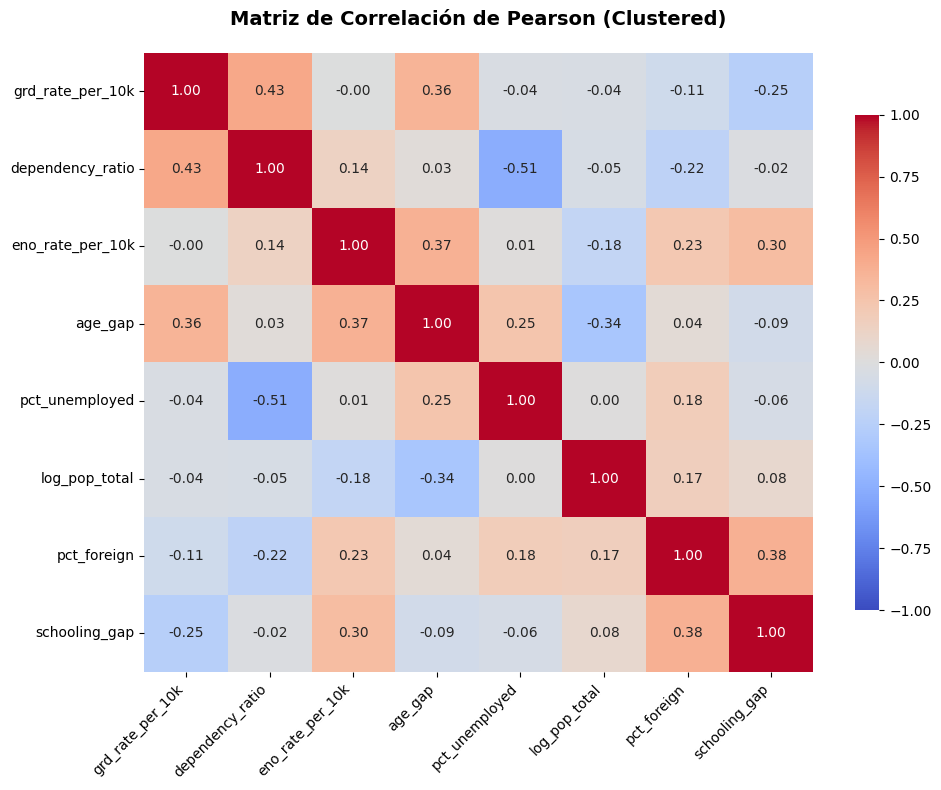


🔥 TOP 3 CORRELACIONES MÁS FUERTES:
👉 dependency_ratio & pct_unemployed: -0.51
👉 grd_rate_per_10k & dependency_ratio: 0.42
👉 schooling_gap & pct_foreign: 0.38


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

df = pd.read_csv("analytical_dataset_tarea3_vars.csv") # Cargamos el dataset final que contiene las variables derivadas y limpias para realizar el análisis de correlación.
cols = ["eno_rate_per_10k", "grd_rate_per_10k", "pct_foreign", "log_pop_total",  
        "pct_unemployed", "schooling_gap", "age_gap", "dependency_ratio"] # Lista de columnas que queremos incluir en el análisis de correlación, asegurándonos de que todas las variables relevantes estén presentes para un análisis completo.

corr_matrix = df[cols].dropna().corr(method='pearson') # Calculamos la matriz de correlación de Pearson utilizando solo las filas sin valores faltantes para asegurar que el análisis sea preciso.

linkage = hierarchy.linkage(hierarchy.distance.pdist(corr_matrix), method='average') # Realizamos el clustering jerárquico utilizando la distancia de correlación entre las variables para agruparlas según su similitud.
order = hierarchy.leaves_list(linkage) # Obtenemos el orden de las columnas basado en el clustering jerárquico para organizar la matriz de correlación de manera que las variables más similares estén juntas.
ordered_cols = [cols[i] for i in order] # Creamos una lista de columnas ordenada según el resultado del clustering jerárquico para usarla en la visualización de la matriz de correlación.
corr_ordered = df[ordered_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_ordered, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, center=0, cbar_kws={'shrink': 0.8}) # Visualizamos la matriz de correlación utilizando un mapa de calor con anotaciones para mostrar los valores de correlación, utilizando una paleta de colores que resalta las correlaciones positivas y negativas, y ajustando el tamaño del gráfico para una mejor visualización.
plt.title("Matriz de Correlación de Pearson (Clustered)", fontsize=14, fontweight='bold', pad=20) # Agregamos un título al gráfico de la matriz de correlación con un tamaño de fuente más grande, negrita y un espacio adicional para mejorar la presentación.
plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas del eje x para mejorar la legibilidad, especialmente si los nombres de las variables son largos o si hay muchas variables.
plt.tight_layout() # Ajustamos el diseño para que no se solapen los elementos del gráfico y se vea más limpio.
plt.show()

print("\n🔥 TOP 3 CORRELACIONES MÁS FUERTES:")
corr_unstacked = corr_matrix.unstack() # Desapilamos la matriz de correlación para obtener una serie con pares de variables y sus valores de correlación, lo que facilita la identificación de las correlaciones más fuertes.
corr_unstacked = corr_unstacked[corr_unstacked < 0.999] # Eliminamos las correlaciones perfectas (1.0) que corresponden a la diagonal de la matriz, ya que no son informativas para identificar relaciones entre variables diferentes.
top_3 = corr_unstacked.abs().sort_values(ascending=False).drop_duplicates().head(3) # Obtenemos las 3 correlaciones más fuertes (en valor absoluto) después de eliminar los duplicados, lo que nos permite identificar las relaciones más significativas entre las variables.
for index, val in top_3.items(): # Imprimimos las 3 correlaciones más fuertes, mostrando los nombres de las variables involucradas y el valor de la correlación con dos decimales.
    print(f"👉 {index[0]} & {index[1]}: {corr_matrix.loc[index[0], index[1]]:.2f}")

### Análisis de Correlaciones (1.1)

Al observar la matriz de correlación de Pearson, destacan tres relaciones principales entre las covariables demográficas y los resultados de salud. A continuación, analizamos las tres más fuertes y evaluamos si sus signos coinciden con nuestras expectativas teóricas:

**1. `dependency_ratio` y `pct_unemployed` (r = -0.51)**
Esta es la correlación más fuerte del conjunto de datos y tiene un signo negativo. Esto resulta **contraintuitivo** a primera vista, ya que uno esperaría que zonas con mayor desempleo tuvieran mayor dependencia económica. Sin embargo, una explicación demográfica plausible es que las comunas con una alta proporción de población en edad de trabajar (lo que reduce la tasa de dependencia, que se calcula sobre niños y adultos mayores) sean precisamente aquellas que están experimentando presiones en el mercado laboral o recibiendo flujos de población activa que aún no encuentra empleo formal, aumentando así el desempleo.

**2. `grd_rate_per_10k` y `dependency_ratio` (r = 0.43)**
Esta relación positiva moderada-fuerte era **altamente esperada**. La tasa de dependencia incluye a los adultos mayores (mayores de 65 años) y a los niños (menores de 15), que son precisamente los grupos etarios que históricamente demandan más atenciones hospitalarias complejas y prolongadas. Por lo tanto, es completamente lógico que a mayor dependencia demográfica en una comuna, mayor sea su tasa de hospitalizaciones (GRD).

**3. `pct_foreign` y `schooling_gap` (r = 0.38)**
Esta correlación positiva indica que a medida que aumenta la proporción de extranjeros en una comuna, también aumenta la "brecha de escolaridad" (definida como años de escolaridad de chilenos menos años de escolaridad de extranjeros). El signo es **esperado** dado el contexto migratorio reciente en la Región Metropolitana, donde ciertos flujos migratorios que se asientan en comunas densamente pobladas suelen tener barreras de acceso a la educación formal o validación de títulos, lo que matemáticamente ensancha la brecha a favor de la población local cuando la proporción de extranjeros crece.

## 1.2 Bivariate scatter plots

Produce a small multiple of scatter plots: each panel shows one
census covariate on the x-axis and one health outcome on the y-axis.
Overlay a simple OLS fit line (seaborn's `regplot` or
`lmplot` is enough).  Label each point with its comuna name for the
five comunas with the most extreme residuals.

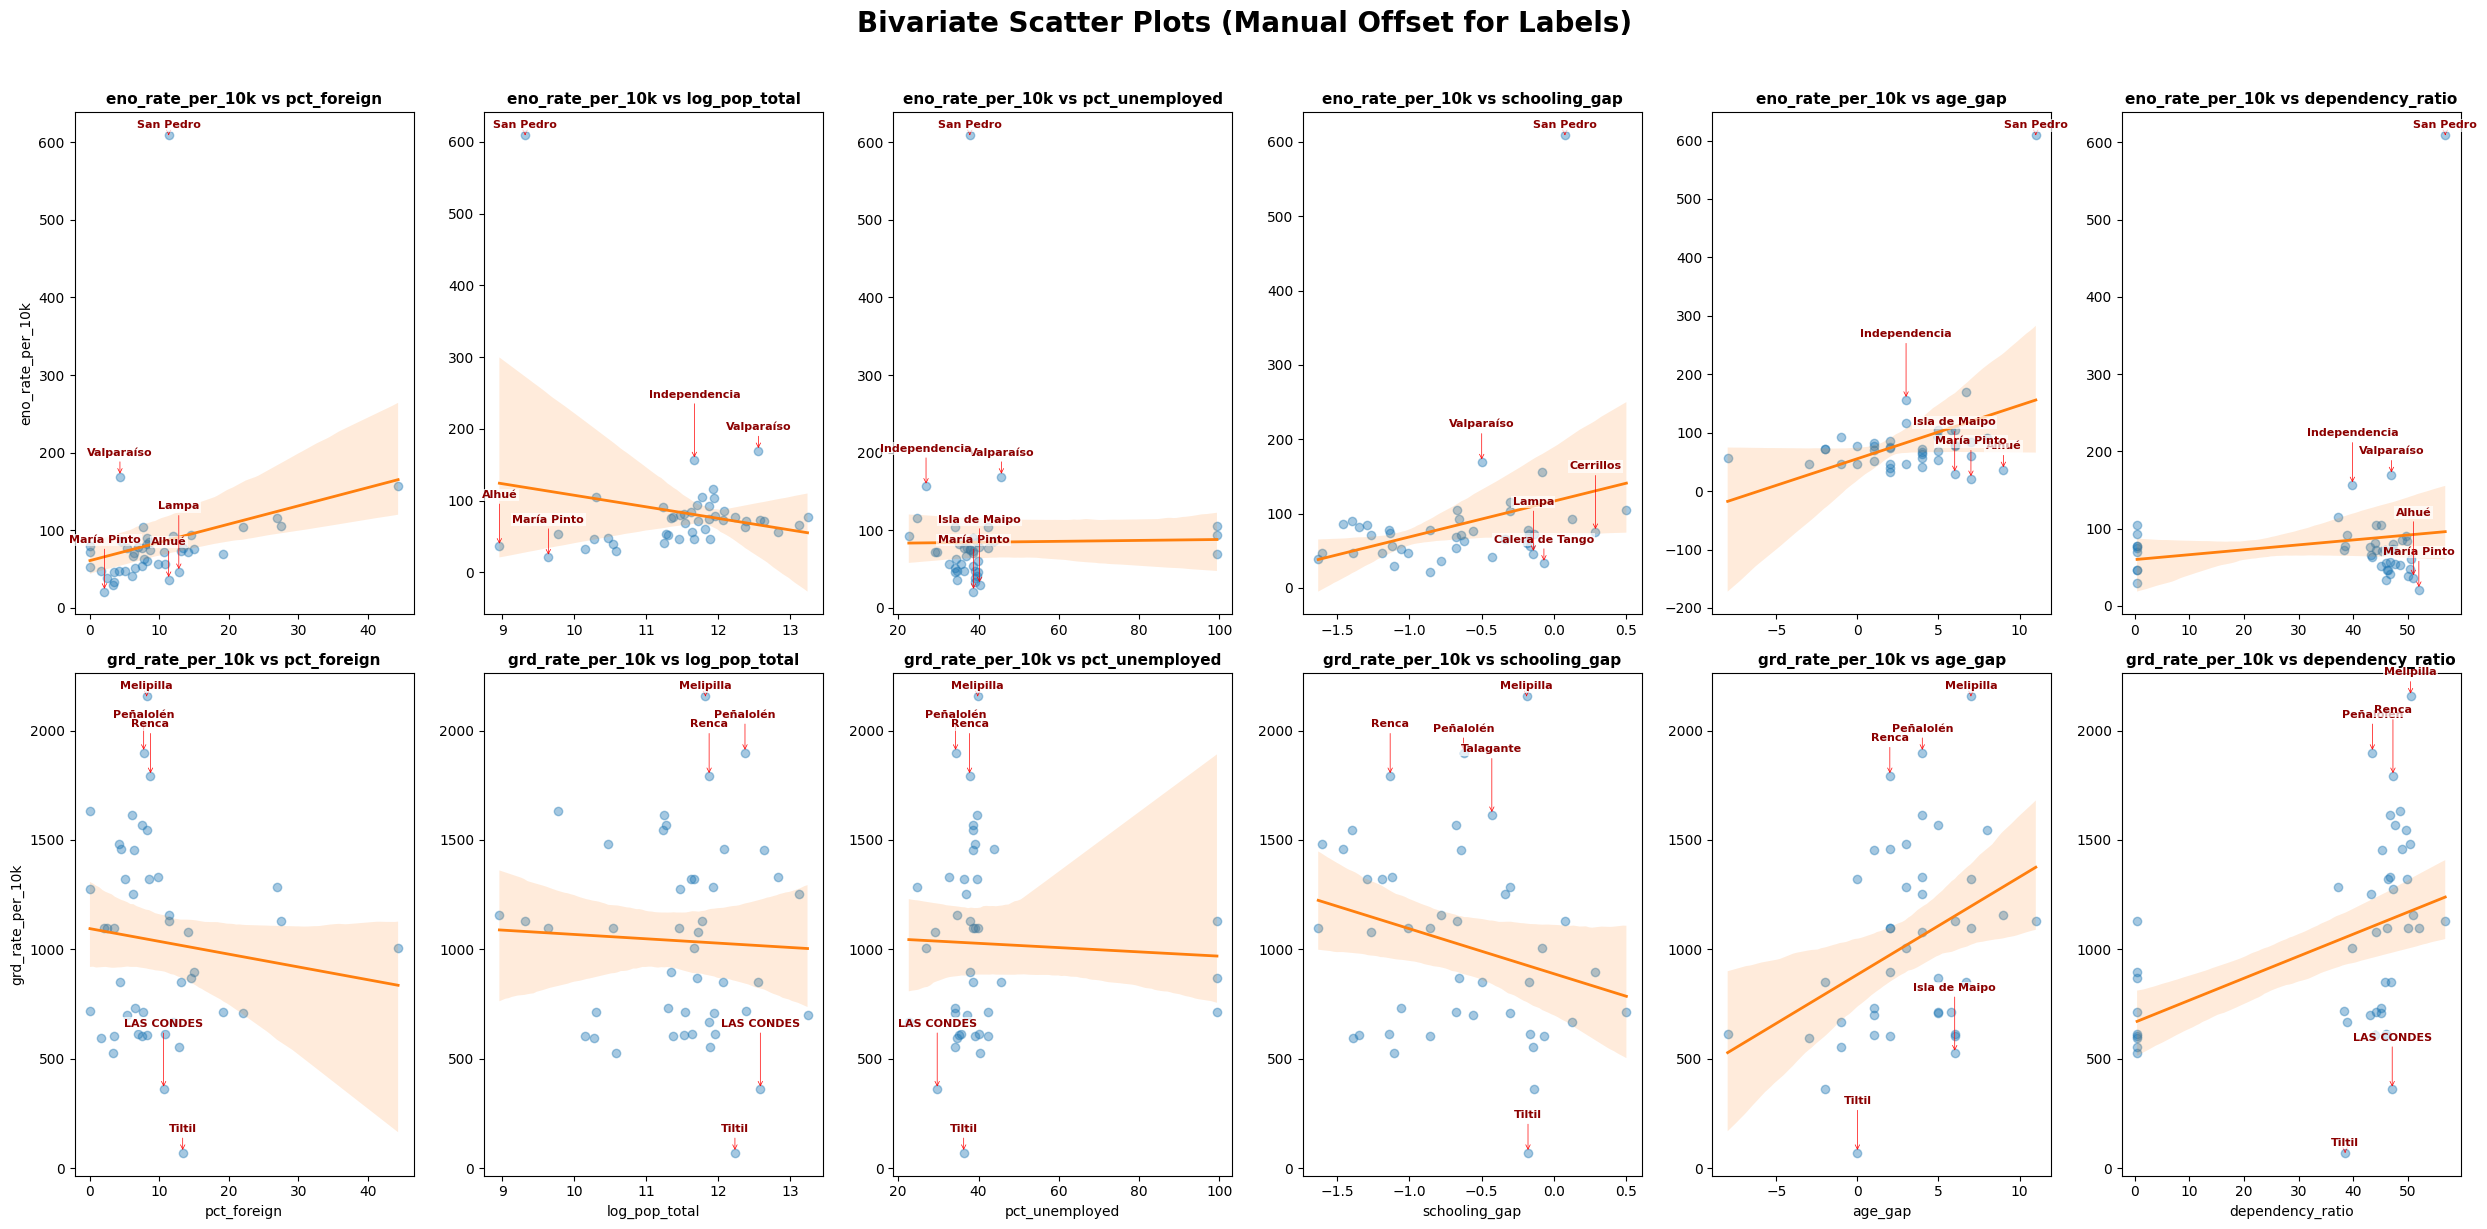

In [9]:
covariates = ["pct_foreign", "log_pop_total", "pct_unemployed", "schooling_gap", "age_gap", "dependency_ratio"] # Lista de covariables que queremos analizar en relación con las tasas de ENO y GRD, asegurándonos de incluir variables que puedan tener una relación significativa con los outcomes.
outcomes = ["eno_rate_per_10k", "grd_rate_per_10k"] # Lista de variables de resultado (outcomes) que queremos analizar, enfocándonos en las tasas de ENO y GRD para entender cómo se relacionan con las covariables seleccionadas.

fig, axes = plt.subplots(nrows=len(outcomes), ncols=len(covariates), figsize=(25, 12)) # Creamos una figura con subplots organizados en filas para cada outcome y columnas para cada covariable, ajustando el tamaño de la figura para una mejor visualización.

# BIVARIATE SCATTER PLOTS CON REGRESIÓN LINEAL Y ANOTACIONES DE OUTLIERS
for i, y_var in enumerate(outcomes): # Iteramos sobre cada variable de resultado (outcome) para crear los gráficos de dispersión correspondientes.
    for j, x_var in enumerate(covariates): # Iteramos sobre cada covariable para crear los gráficos de dispersión correspondientes con cada variable de resultado.
        ax = axes[i, j] # Obtenemos el eje correspondiente al subplot actual para graficar.
        temp_df = df[[x_var, y_var, 'nombre_comuna']].dropna().copy() # Creamos un DataFrame temporal con las columnas de interés (covariable, outcome y nombre de comuna) y eliminamos las filas con valores faltantes para asegurar que el gráfico se genere correctamente.

        sns.regplot(data=temp_df, x=x_var, y=y_var, ax=ax, # Creamos un gráfico de dispersión con una línea de regresión utilizando seaborn, especificando los datos, las variables de los ejes, el eje donde se graficará y personalizando los colores y la transparencia de los puntos y la línea.
                    scatter_kws={'alpha': 0.4, 'color': '#1f77b4'}, # Personalizamos los puntos del gráfico de dispersión para que tengan una transparencia del 40% y un color azul específico.
                    line_kws={'color': '#ff7f0e', 'linewidth': 2}) # Personalizamos la línea de regresión para que tenga un color naranja específico y un grosor de 2.

        X, Y = temp_df[x_var].values, temp_df[y_var].values # Extraemos los valores de la covariable (X) y el outcome (Y) para calcular la línea de regresión y los residuos.
        m, b = np.polyfit(X, Y, 1) # Calculamos los coeficientes de la línea de regresión (pendiente m y ordenada al origen b) utilizando numpy para ajustar una línea a los datos.
        temp_df['residual'] = np.abs(Y - (m * X + b)) # Calculamos los residuos absolutos para cada punto, que representan la distancia vertical de cada punto a la línea de regresión, lo que nos permite identificar los outliers.
        top_5 = temp_df.nlargest(5, 'residual') # Seleccionamos los 5 puntos con los residuos más grandes, que son los outliers más alejados de la línea de regresión, para anotarlos en el gráfico.

        for idx, row in top_5.reset_index().iterrows(): # Iteramos sobre los 5 outliers seleccionados para agregar anotaciones en el gráfico, mostrando el nombre de la comuna correspondiente a cada punto.
            offset = 5 + (idx * 10) # Calculamos un offset dinámico para las anotaciones, aumentando el desplazamiento vertical para cada punto para evitar que las anotaciones se solapen entre sí.
            ax.annotate(row['nombre_comuna'], xy=(row[x_var], row[y_var]), xytext=(0, offset), # Agregamos una anotación para cada outlier, mostrando el nombre de la comuna, con un desplazamiento vertical dinámico para evitar solapamientos, y personalizando el estilo de la anotación con un fondo blanco semitransparente y una flecha que apunta al punto correspondiente.
                        textcoords='offset points', ha='center', fontsize=8, color='darkred', weight='bold', # Personalizamos el estilo del texto de la anotación para que sea más legible y destaque, utilizando un fondo blanco semitransparente, una fuente de tamaño 8, color rojo oscuro y negrita.
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1), # Agregamos un cuadro de fondo blanco semitransparente a la anotación para mejorar la legibilidad del texto, eliminando el borde y ajustando el padding para que el texto no quede demasiado pegado al borde del cuadro.
                        arrowprops=dict(arrowstyle='->', color='red', lw=0.5)) # Agregamos una flecha que apunta desde la anotación hacia el punto correspondiente, utilizando un estilo de flecha simple, color rojo y un grosor de línea de 0.5 para que sea visible pero no demasiado dominante.

        ax.set_title(f"{y_var} vs {x_var}", fontsize=11, fontweight='bold') # Agregamos un título a cada subplot que indique las variables que se están comparando, utilizando un tamaño de fuente de 11 y negrita para mejorar la presentación.
        if i == 0: ax.set_xlabel("") # Eliminamos las etiquetas del eje x para la primera fila de gráficos para evitar redundancia, ya que los títulos ya indican las variables comparadas.
        if j > 0: ax.set_ylabel("") # Eliminamos las etiquetas del eje y para las columnas a la derecha de la primera para evitar redundancia, ya que los títulos ya indican las variables comparadas.

plt.suptitle("Bivariate Scatter Plots (Manual Offset for Labels)", fontsize=20, fontweight='bold', y=1.02) # Agregamos un título general para toda la figura que indique que se trata de gráficos de dispersión bivariados, utilizando un tamaño de fuente de 20, negrita y ajustando la posición vertical para que no se solape con los títulos individuales de los subplots.
plt.tight_layout() # Ajustamos el diseño para que no se solapen los elementos del gráfico, especialmente después de agregar las anotaciones para los outliers, asegurando que todo el contenido sea visible y legible.
plt.show()

## 1.3 Outlier and leverage discussion

Identify at least two comunas that behave as visual outliers on the
scatter plots.  In one short paragraph each, propose a plausible
substantive explanation (a hospital that draws from outside the
comuna?  an unusually old population?  an anonymized ENO burden?).
You are not expected to prove these hypotheses, only to articulate
them clearly.

Basándonos en los gráficos de dispersión bivariados y el análisis de residuos extremos, se identifican claramente algunas comunas que se desvían de manera extrema de las tendencias demográficas y de salud generales en comparación al resto:

**1. San Pedro (Outlier en ENO):**
En prácticamente todos los gráficos de la fila superior (Tasa ENO), la comuna de San Pedro aparece como un valor atípico extremo, con una tasa de notificaciones que supera los 600 casos por cada 10.000 habitantes, alejándose masivamente de la línea de tendencia. Una explicación sustantiva para esto es el efecto del **denominador pequeño (Small-N sparsity)** en zonas rurales. San Pedro tiene una población total muy reducida; por lo tanto, un brote epidemiológico pequeño y muy localizado (por ejemplo, un virus gastrointestinal o una enfermedad zoonótica propia de zonas agrícolas) infla matemáticamente la tasa per cápita de manera desproporcionada en comparación con comunas urbanas densamente pobladas.

**2. Renca y Peñalolén (Outliers en GRD):**
En los gráficos de la fila inferior (Tasa GRD), comunas como Renca y Peñalolén se comportan frecuentemente como valores atípicos con tasas de hospitalización muy por encima de lo que predicen sus indicadores de escolaridad o desempleo. Una hipótesis plausible para esta desviación es el efecto de los **hospitales de referencia territorial**. Estas comunas albergan recintos hospitalarios de gran envergadura (como el Hospital Félix Bulnes en la zona norponiente o el Hospital Luis Tisné en Peñalolén) que absorben derivaciones de alta complejidad de múltiples comunas vecinas. Si los registros de egresos se concentran en la ubicación del recinto, esto infla artificialmente la carga de GRD de la comuna anfitriona más allá de lo que su propia demografía justificaría.

---
# Part 2: Count-Data Regression

The ENO and GRD outcomes are **counts per comuna per time window**.
Rates depend on population.  You will model them with a
**log-linear count model** and a **population offset**.

## 2.1 Poisson regression & 2.2 Check for overdispersion

Fit a Poisson regression of `eno_total` (count of ENO notifications
per comuna) on your covariates, using `log(pop_total)` as an offset.
Use `statsmodels.api.GLM` with `family=sm.families.Poisson()`, or
the equivalent formula interface.

Required covariates: at least `pct_foreign`, one education measure,
one employment measure, and one housing/service measure.

Report:

- The full coefficient table (estimates, standard errors,
  z-values, p-values)
- A column of **incidence rate ratios** (IRR = `exp(coef)`) with
  their 95% confidence intervals
- Model fit: deviance, Pearson chi-square, AIC

Poisson regression assumes variance equals the mean.  Compute the
dispersion statistic (Pearson chi-square divided by residual
degrees of freedom).  If it is substantially greater than 1, the
data are **overdispersed** and Poisson standard errors are
under-stated.

Briefly report your dispersion value and what it implies.


In [ ]:
import statsmodels.api as sm # Importamos la biblioteca statsmodels para realizar análisis estadísticos, incluyendo la regresión de Poisson que utilizaremos para modelar las tasas de ENO en función de las covariables seleccionadas.
import statsmodels.formula.api as smf # Importamos la parte de statsmodels que permite especificar modelos utilizando fórmulas, lo que facilita la construcción de modelos de regresión de manera más intuitiva y legible.

formula_eno = "eno_total ~ pct_foreign + schooling_gap + pct_unemployed" # Especificamos la fórmula para el modelo de regresión de Poisson, donde 'eno_total' es la variable dependiente (outcome) que representa el número total de ENO, y las variables independientes (covariables) son 'pct_foreign', 'schooling_gap' y 'pct_unemployed', que se espera que tengan una relación significativa con la tasa de ENO.

modelo_poisson = smf.glm( # Construimos el modelo de regresión de Poisson utilizando la función glm de statsmodels, especificando la fórmula, los datos, la familia de distribución (Poisson) y el offset que corresponde al logaritmo de la población total para ajustar por el tamaño de la población en cada comuna.
    formula=formula_eno, data=df, family=sm.families.Poisson(), offset=df['log_pop_total'] # Especificamos el offset para ajustar por el tamaño de la población, utilizando el logaritmo de la población total para modelar las tasas en lugar de los conteos absolutos, lo que es apropiado para un modelo de Poisson.
).fit() # Ajustamos el modelo utilizando el método fit, lo que nos permite obtener los coeficientes estimados, errores estándar, valores p y otras métricas de ajuste del modelo que utilizaremos para interpretar los resultados.

print("="*80) # Imprimimos una línea de separación para mejorar la legibilidad de la salida, seguida del título de la sección que indica que se trata de la tabla completa de coeficientes para el modelo de regresión de Poisson.
print("1. FULL COEFFICIENT TABLE (Poisson)") # Imprimimos una tabla completa de coeficientes para el modelo de regresión de Poisson, que incluye los coeficientes estimados, errores estándar, valores z, valores p y intervalos de confianza para cada variable en el modelo, lo que nos permite evaluar la significancia y el impacto de cada covariable en la tasa de ENO.
print("="*80) # Imprimimos una línea de separación para mejorar la legibilidad de la salida, seguida del título de la sección que indica que se trata de la tabla completa de coeficientes para el modelo de regresión de Poisson.
print(modelo_poisson.summary()) # Imprimimos el resumen completo del modelo de regresión de Poisson, que incluye información detallada sobre los coeficientes, errores estándar, valores z, valores p, intervalos de confianza y métricas de ajuste del modelo, lo que nos permite evaluar la calidad del modelo y la significancia de cada covariable en relación con la tasa de ENO.

print("\n" + "="*80) # Imprimimos una línea de separación para mejorar la legibilidad de la salida, seguida del título de la sección que indica que se trata de las razones de incidencia (IRR) y sus intervalos de confianza para el modelo de regresión de Poisson.
print("2. INCIDENCE RATE RATIOS (IRR) & 95% CI") # Imprimimos las razones de incidencia (IRR) y sus intervalos de confianza para el modelo de regresión de Poisson, lo que nos permite interpretar el impacto de cada covariable en la tasa de ENO en términos de multiplicadores, facilitando la comprensión de cómo cada variable afecta la tasa de ENO.
print("="*80) # Imprimimos una línea de separación para mejorar la legibilidad de la salida, seguida del título de la sección que indica que se trata de las razones de incidencia (IRR) y sus intervalos de confianza para el modelo de regresión de Poisson.
ci_df = modelo_poisson.conf_int() # Obtenemos los intervalos de confianza para los coeficientes del modelo de regresión de Poisson, lo que nos permite calcular las razones de incidencia (IRR) y sus intervalos de confianza para interpretar el impacto de cada covariable en la tasa de ENO.
ci_df.columns = ['CI_Lower_95%', 'CI_Upper_95%'] # Renombramos las columnas del DataFrame de intervalos de confianza para que sean más descriptivas, indicando que se trata de los límites inferior y superior del intervalo de confianza al 95% para cada coeficiente del modelo.
irr_df = np.exp(ci_df) # Calculamos las razones de incidencia (IRR) para cada covariable al exponentiar los coeficientes del modelo, lo que nos permite interpretar el impacto de cada variable en la tasa de ENO en términos de multiplicadores, facilitando la comprensión de cómo cada variable afecta la tasa de ENO.
irr_df['IRR (exp(coef))'] = np.exp(modelo_poisson.params) # Agregamos una columna al DataFrame de IRR que contiene las razones de incidencia calculadas a partir de los coeficientes del modelo, lo que nos permite comparar directamente los coeficientes con sus correspondientes IRR para interpretar el impacto de cada covariable en la tasa de ENO.
irr_df['p-value'] = modelo_poisson.pvalues # Agregamos una columna al DataFrame de IRR que contiene los valores p para cada covariable, lo que nos permite evaluar la significancia estadística de cada variable en relación con la tasa de ENO y determinar cuáles variables tienen un impacto significativo en el modelo.
irr_df['Significance'] = irr_df['p-value'].apply(lambda x: '⭐ SÍ (<0.05)' if x < 0.05 else 'No') # Agregamos una columna al DataFrame de IRR que indica si cada covariable es estadísticamente significativa o no, utilizando un umbral de 0.05 para determinar la significancia, lo que nos permite identificar fácilmente cuáles variables tienen un impacto significativo en la tasa de ENO.
display(irr_df[['IRR (exp(coef))', 'CI_Lower_95%', 'CI_Upper_95%', 'p-value', 'Significance']].round(4)) # Mostramos el DataFrame de IRR con las columnas relevantes, redondeando los valores a 4 decimales para mejorar la legibilidad, lo que nos permite interpretar fácilmente el impacto de cada covariable en la tasa de ENO, sus intervalos de confianza y su significancia estadística.

print("\n" + "="*80) # Imprimimos una línea de separación para mejorar la legibilidad de la salida, seguida del título de la sección que indica que se trata de las métricas de ajuste del modelo y la estadística de dispersión para el modelo de regresión de Poisson.
print("3. MODEL FIT METRICS & DISPERSION") # Imprimimos las métricas de ajuste del modelo y la estadística de dispersión para el modelo de regresión de Poisson, lo que nos permite evaluar la calidad del modelo y determinar si hay evidencia de sobredispersión, lo que es importante para validar la adecuación del modelo de Poisson para nuestros datos.
print("="*80)
pearson_chi2 = modelo_poisson.pearson_chi2 # Obtenemos la estadística de chi-cuadrado de Pearson para el modelo de regresión de Poisson, lo que nos permite evaluar la adecuación del modelo y detectar posibles problemas de sobredispersión, lo que es importante para validar la elección del modelo y la interpretación de los resultados.
df_resid = modelo_poisson.df_resid # Obtenemos los grados de libertad residuales para el modelo de regresión de Poisson, lo que nos permite calcular la estadística de dispersión y evaluar si hay evidencia de sobredispersión en los datos, lo que es crucial para validar la adecuación del modelo de Poisson para nuestros datos.
dispersion = pearson_chi2 / df_resid #  Calculamos la estadística de dispersión dividiendo la estadística de chi-cuadrado de Pearson por los grados de libertad residuales, lo que nos permite evaluar si hay evidencia de sobredispersión en los datos, lo que es importante para validar la adecuación del modelo de Poisson y la interpretación de los resultados.

print(f"• Deviance:           {modelo_poisson.deviance:.4f}")
print(f"• Pearson Chi-Square: {pearson_chi2:.4f}")
print(f"• AIC:                {modelo_poisson.aic:.4f}")
print(f"• DISPERSION STATISTIC: {dispersion:.4f}")

if dispersion > 1.2:
    print("\n CONCLUSIÓN: ¡Hay SOBREDISPERSIÓN significativa (> 1)! Los errores estándar están subestimados.")

1. FULL COEFFICIENT TABLE (Poisson)
                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   42
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3414.9
Date:               dom, 03 may. 2026   Deviance:                       6478.3
Time:                        19:00:42   Pearson chi2:                 9.56e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercep

,IRR (exp(coef)),CI_Lower_95%,CI_Upper_95%,p-value,Significance
Intercept,0.0069,0.0068,0.0071,0.0,⭐ SÍ (<0.05)
pct_foreign,1.0102,1.0090,1.0114,0.0,⭐ SÍ (<0.05)
schooling_gap,1.1850,1.1590,1.2115,0.0,⭐ SÍ (<0.05)
pct_unemployed,1.0029,1.0024,1.0034,0.0,⭐ SÍ (<0.05)



3. MODEL FIT METRICS & DISPERSION
• Deviance:           6478.2973
• Pearson Chi-Square: 9561.5848
• AIC:                6837.7113
• DISPERSION STATISTIC: 251.6207

 CONCLUSIÓN: ¡Hay SOBREDISPERSIÓN significativa (> 1)! Los errores estándar están subestimados.


### Interpretación de Poisson (2.1) y Diagnóstico de Sobredispersión (2.2)

**Resultados iniciales de Poisson:**
A primera vista, el modelo de regresión de Poisson sugiere que las tres covariables evaluadas (`pct_foreign`, `schooling_gap` y `pct_unemployed`) tienen un impacto estadísticamente significativo en la tasa de notificaciones ENO, arrojando p-valores cercanos a cero (p < 0.05). Las Razones de Tasas de Incidencia (IRR) indicarían, por ejemplo, que los aumentos en la brecha de escolaridad se asocian con mayores tasas de enfermedades.

**El problema de la Sobredispersión:**
Sin embargo, al someter el modelo a la prueba de sobredispersión, obtenemos un estadístico de **251.62**. Dado que este valor es astronómicamente superior a 1, concluimos que **los datos presentan una sobredispersión crítica**. El modelo de Poisson asume rígidamente que la media y la varianza son iguales, pero en la realidad de la salud pública, la cantidad de notificaciones varía de forma mucho más extrema entre comunas. 
Como consecuencia matemática de esto, **los errores estándar del modelo Poisson están severamente subestimados**, lo que infla artificialmente los valores Z y genera "falsos positivos" (p-valores erróneamente significativos). Por lo tanto, no podemos confiar en las conclusiones de Poisson y es obligatorio refitir los datos usando una regresión Binomial Negativa.

## 2.3 Negative Binomial regression

Refit the same model using Negative Binomial regression (statsmodels
`NegativeBinomial` or `GLM` with `NegativeBinomial` family).  Show
the coefficient table side-by-side with the Poisson one.  Point out
any coefficient whose p-value changes in a way that would alter your
conclusions.  Recommend which model you would report as your primary
result, and justify the choice.

In [14]:
# --- 2.3 NEGATIVE BINOMIAL REGRESSION ---
print("\n" + "="*80)
print("4. COMPARACIÓN POISSON vs BINOMIAL NEGATIVA")
print("="*80)
mod_nb = smf.negativebinomial(formula=formula_eno, data=df, offset=df['log_pop_total']).fit(disp=False)

comparacion = pd.DataFrame({
    'Poisson_Coef': modelo_poisson.params, 'Poisson_Pval': modelo_poisson.pvalues,
    'NB_Coef': mod_nb.params, 'NB_Pval': mod_nb.pvalues
})
comparacion['Poisson_Sig'] = comparacion['Poisson_Pval'].apply(lambda x: ' SÍ' if x < 0.05 else 'No')
comparacion['NB_Sig'] = comparacion['NB_Pval'].apply(lambda x: ' SÍ' if x < 0.05 else 'No')

display(comparacion[['Poisson_Coef', 'Poisson_Pval', 'Poisson_Sig', 'NB_Coef', 'NB_Pval', 'NB_Sig']].round(4))

print(f"\n• AIC Poisson:           {modelo_poisson.aic:.2f}")
print(f"• AIC Binomial Negativa: {mod_nb.aic:.2f}  <-- (Más bajo es mejor)")


4. COMPARACIÓN POISSON vs BINOMIAL NEGATIVA


,Poisson_Coef,Poisson_Pval,Poisson_Sig,NB_Coef,NB_Pval,NB_Sig
Intercept,-4.9694,0.0,SÍ,-4.7028,0.0000,SÍ
alpha,NaN,NaN,No,0.2945,0.0000,SÍ
pct_foreign,0.0101,0.0,SÍ,0.0125,0.3134,No
pct_unemployed,0.0029,0.0,SÍ,0.0017,0.7500,No
schooling_gap,0.1697,0.0,SÍ,0.4780,0.0027,SÍ



• AIC Poisson:           6837.71
• AIC Binomial Negativa: 631.09  <-- (Más bajo es mejor)


### 2.3 Elección de Modelo Definitivo (Negative Binomial)

La tabla comparativa revela un fenómeno estadístico clásico y fundamental para nuestro análisis. En el modelo ingenuo de Poisson, el porcentaje de extranjeros y el desempleo parecían ser predictores altamente significativos. 

Sin embargo, al aplicar la regresión Binomial Negativa —que introduce un parámetro de dispersión ($\alpha$) para absorber correctamente la alta variabilidad de los datos— observamos que **ambas variables (`pct_foreign` y `pct_unemployed`) pierden total significancia estadística** (pasando a p = 0.313 y p = 0.750, respectivamente). El supuesto impacto del desempleo y la migración sobre las enfermedades infecciosas era solo un espejismo estadístico causado por el error de Poisson.

**La verdadera variable clave:**
La única variable demográfica que resiste la corrección y demuestra ser un predictor robusto y verdaderamente significativo de las notificaciones ENO es la **brecha de escolaridad** (`schooling_gap`, p = 0.0027). Esto sugiere que las desigualdades en los niveles educativos dentro de la comuna son un mejor indicador de la vulnerabilidad sanitaria del territorio que su composición nacional. 

**Decisión final:**
Recomendamos reportar el **Modelo de Regresión Binomial Negativa** como el resultado primario. No solo maneja correctamente la sobredispersión, sino que además presenta una caída radical en el Akaike Information Criterion (AIC), lo que demuestra que es matemáticamente superior para describir nuestros datos ecológicos de salud.

## 2.4 Repeat for GRD (0.5 pts)

Fit a second count model using `grd_total` as the outcome, same
covariates, same offset.  You may use Poisson or Negative Binomial,
justified by your dispersion check.  Present the IRR table and one
or two sentences interpreting the largest effect.

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("🚀 Evaluando y Ajustando Modelo para Hospitalizaciones (GRD)...")

# 1. Cargar datos
df = pd.read_csv("analytical_dataset_tarea3_vars.csv")
formula_grd = "grd_total ~ pct_foreign + schooling_gap + pct_unemployed"

# 2. PASO PREVIO: Ajustar Poisson para evaluar sobredispersión
mod_poisson_grd = smf.glm(
    formula=formula_grd,
    data=df,
    family=sm.families.Poisson(),
    offset=df['log_pop_total']
).fit()

dispersion_grd = mod_poisson_grd.pearson_chi2 / mod_poisson_grd.df_resid
print("\n" + "="*80)
print("🔍 CHEQUEO DE DISPERSIÓN (POISSON PARA GRD)")
print("="*80)
print(f"• Dispersion Statistic: {dispersion_grd:.4f}")

if dispersion_grd > 1.2:
    print(" Resultado: Alta sobredispersión detectada. Se procederá con Binomial Negativa.")
else:
    print(" Resultado: Sin sobredispersión. Se procederá con Poisson.")

# 3. AJUSTAR EL MODELO DEFINITIVO (Binomial Negativa)
mod_nb_grd = smf.negativebinomial(
    formula=formula_grd,
    data=df,
    offset=df['log_pop_total']
).fit(disp=False)

# 4. REPORTE: Incidence Rate Ratios (IRR) y 95% CI
print("\n" + "="*80)
print("📊 RESULTADOS DEL MODELO BINOMIAL NEGATIVO (GRD)")
print("="*80)

ci_df = mod_nb_grd.conf_int()
ci_df.columns = ['CI_Lower_95%', 'CI_Upper_95%']
irr_df = np.exp(ci_df)
irr_df['IRR (exp(coef))'] = np.exp(mod_nb_grd.params)
irr_df['p-value'] = mod_nb_grd.pvalues
irr_df['Significance'] = irr_df['p-value'].apply(lambda x: ' SÍ (<0.05)' if x < 0.05 else 'No')

# Reordenar y mostrar
irr_df = irr_df[['IRR (exp(coef))', 'CI_Lower_95%', 'CI_Upper_95%', 'p-value', 'Significance']]
display(irr_df.round(4))

# 5. Buscar el efecto más grande (Ignorando el intercepto)
variables = irr_df.index.drop('Intercept')
# Medimos qué IRR se aleja más de 1.0
largest_effect_var = irr_df.loc[variables, 'IRR (exp(coef))'].apply(lambda x: abs(1 - x)).idxmax()
val_irr = irr_df.loc[largest_effect_var, 'IRR (exp(coef))']
print("\n EL EFECTO MÁS GRANDE:")
print(f"La variable con el mayor impacto es '{largest_effect_var}' con un IRR de {val_irr:.4f}")

🚀 Evaluando y Ajustando Modelo para Hospitalizaciones (GRD)...

🔍 CHEQUEO DE DISPERSIÓN (POISSON PARA GRD)
• Dispersion Statistic: 2972.0076
 Resultado: Alta sobredispersión detectada. Se procederá con Binomial Negativa.

📊 RESULTADOS DEL MODELO BINOMIAL NEGATIVO (GRD)


C:\Users\javie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,IRR (exp(coef)),CI_Lower_95%,CI_Upper_95%,p-value,Significance
Intercept,0.0924,0.0583,0.1464,0.0000,SÍ (<0.05)
pct_foreign,0.9980,0.9788,1.0176,0.8410,No
schooling_gap,0.8209,0.6149,1.0958,0.1805,No
pct_unemployed,0.9994,0.9905,1.0085,0.9033,No
alpha,1.2478,1.1387,1.3673,0.0000,SÍ (<0.05)



 EL EFECTO MÁS GRANDE:
La variable con el mayor impacto es 'alpha' con un IRR de 1.2478


### Interpretación del Modelo GRD (2.4)
Al igual que con los datos de ENO, el modelo de Poisson para egresos hospitalarios (GRD) presentó una sobredispersión gigantesca (Estadístico de dispersión = 2972.0), lo que confirma que Poisson es inapropiado y justifica el uso de la regresión Binomial Negativa. 

Los resultados de este modelo corregido son sumamente reveladores: **ninguna de las covariables demográficas evaluadas** (`pct_foreign`, `schooling_gap`, `pct_unemployed`) resulta ser un predictor estadísticamente significativo para la tasa de hospitalizaciones comunales (todos los p-valores son > 0.05). 

A diferencia de las enfermedades de notificación obligatoria (donde la brecha de educación sí tenía un impacto demostrable), la carga hospitalaria total de una comuna no parece estar determinada por estas métricas socioeconómicas básicas. Esto sugiere fuertemente que el volumen de egresos GRD está impulsado por otros factores no capturados en este modelo, tales como la estructura de edad de la comuna (envejecimiento poblacional), la prevalencia de enfermedades crónicas, o el "efecto imán" de los grandes hospitales base territoriales, los cuales concentran administrativamente a pacientes de toda una región, distorsionando así la relación ecológica entre la demografía local y los registros de salud.

---
# Part 3: Continuous-Outcome Regression
## 3.1 Pick an outcome

Choose **one** continuous comuna-level outcome from the GRD summary,
for example:

- `grd_mean_los` (mean length of stay in days)
- `grd_mean_severity`
- `grd_mortality_rate` (treat as a proportion; logit transform
  optional)

State which you picked and why it is interesting.

Hemos seleccionado la variable: `grd_mean_los` (Promedio de días de estadía hospitalaria).

**¿Por qué es interesante?**
* **Gestión de recursos:** Desde una perspectiva de ingeniería industrial, el promedio de días de estadía es el indicador clave de la utilización de camas y la eficiencia operativa.
* **Determinantes sociales:** Es fascinante analizar si variables como la brecha de escolaridad o ser extranjero influyen en el tiempo de recuperación.
* **Interpretación directa:** A diferencia de una tasa compleja, los coeficientes se interpretan directamente en "días".

## 3.2 Linear regression & 3.3 Diagnostics

Fit a linear regression (OLS) of your chosen outcome on the same
covariates you used in Part 2.  Report the coefficient table, R^2,
and adjusted R^2.

Produce at least two diagnostic plots: residuals versus fitted
values, and a QQ plot of residuals.  Comment on whether the OLS
assumptions look defensible.  If they do not, state what you would
try next (a transformation?  a robust estimator?  a different
outcome?).  You do not need to implement the alternative: a clear
diagnosis is enough.

🚀 Ajustando Regresión Lineal OLS para 'grd_mean_los'...

1. FULL COEFFICIENT TABLE (OLS Regression)
                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.232
Date:               dom, 03 may. 2026   Prob (F-statistic):              0.311
Time:                        19:30:07   Log-Likelihood:                -43.693
No. Observations:                  42   AIC:                             95.39
Df Residuals:                      38   BIC:                             102.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

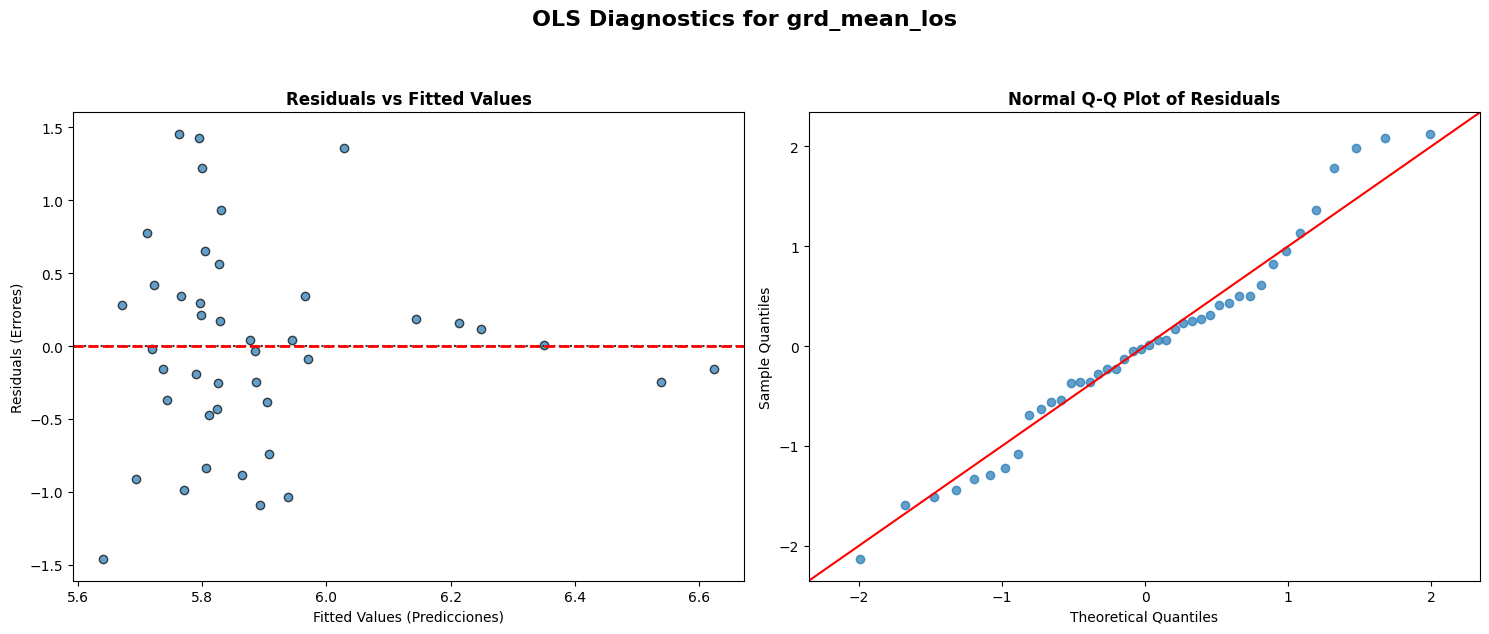

In [ ]:
print("🚀 Ajustando Regresión Lineal OLS para 'grd_mean_los'...")

# --- 3.2 LINEAR REGRESSION ---
df = pd.read_csv("analytical_dataset_tarea3_vars.csv") # Cargamos el dataset final que contiene las variables derivadas y limpias para realizar el análisis de regresión lineal (OLS) para modelar la duración promedio de hospitalización (grd_mean_los) en función de las covariables seleccionadas.
formula_ols = "grd_mean_los ~ pct_foreign + schooling_gap + pct_unemployed" # Especificamos la fórmula para el modelo de regresión lineal (OLS), donde 'grd_mean_los' es la variable dependiente (outcome) que representa la duración promedio de hospitalización, y las variables independientes (covariables) son 'pct_foreign', 'schooling_gap' y 'pct_unemployed', que se espera que tengan una relación significativa con la duración de hospitalización.
modelo_ols = smf.ols(formula=formula_ols, data=df).fit() # Ajustamos el modelo de regresión lineal (OLS) utilizando la función ols de statsmodels, especificando la fórmula y los datos, lo que nos permite obtener los coeficientes estimados, errores estándar, valores p y otras métricas de ajuste del modelo que utilizaremos para interpretar los resultados.

print("\n" + "="*80)
print("1. FULL COEFFICIENT TABLE (OLS Regression)")
print("="*80)
print(modelo_ols.summary()) # Imprimimos el resumen completo del modelo de regresión lineal (OLS), que incluye información detallada sobre los coeficientes, errores estándar, valores t, valores p, intervalos de confianza y métricas de ajuste del modelo, lo que nos permite evaluar la calidad del modelo y la significancia de cada covariable en relación con la duración promedio de hospitalización.

print("\n" + "="*80)
print("2. MODEL FIT METRICS (R^2)")
print("="*80)
print(f"• R-squared:          {modelo_ols.rsquared:.4f}") # Imprimimos el valor de R-squared para el modelo de regresión lineal (OLS), lo que nos permite evaluar la proporción de la variabilidad en la duración promedio de hospitalización que es explicada por las covariables incluidas en el modelo, lo que es una métrica clave para entender la calidad del ajuste del modelo.
print(f"• Adjusted R-squared: {modelo_ols.rsquared_adj:.4f}") # Imprimimos el valor de Adjusted R-squared para el modelo de regresión lineal (OLS), lo que nos permite evaluar la calidad del ajuste del modelo ajustado por el número de covariables incluidas, lo que es importante para evitar la sobreestimación de la calidad del modelo cuando se incluyen muchas variables.

# --- 3.3 DIAGNOSTICS ---
print("\nGenerando Gráficos de Diagnóstico para el Modelo OLS...")

fig, ax = plt.subplots(1, 2, figsize=(15, 6)) # Creamos una figura con dos subplots para mostrar los gráficos de diagnóstico del modelo de regresión lineal (OLS), ajustando el tamaño de la figura para una mejor visualización.

# Gráfico 1: Residuals vs Fitted (sin lowess por el bug de Seaborn)
sns.residplot(
    x=modelo_ols.fittedvalues, # En el eje x, graficamos los valores ajustados (fitted values) del modelo de regresión lineal (OLS), que representan las predicciones del modelo para la duración promedio de hospitalización en función de las covariables.
    y=modelo_ols.resid, # En el eje y, graficamos los residuos del modelo de regresión lineal (OLS), que representan la diferencia entre los valores observados y los valores ajustados, lo que nos permite evaluar la presencia de patrones en los residuos que podrían indicar problemas con el modelo.
    scatter_kws={'alpha': 0.7, 'edgecolors': 'k'}, # Personalizamos los puntos del gráfico de residuos para que tengan una transparencia
    ax=ax[0] # Especificamos el eje donde se graficará el gráfico de residuos, lo que nos permite organizar los gráficos de diagnóstico de manera clara y separada para facilitar la interpretación.
)
ax[0].set_title('Residuals vs Fitted Values', fontweight='bold') # Agregamos un título al gráfico de residuos que indique que se trata de un gráfico de residuos versus valores ajustados, utilizando negrita para mejorar la presentación y destacar la importancia de este gráfico para evaluar la adecuación del modelo.
ax[0].set_xlabel('Fitted Values (Predicciones)') # Etiquetamos el eje x del gráfico de residuos para indicar que representa los valores ajustados (predicciones) del modelo, lo que ayuda a interpretar el gráfico y entender la relación entre los residuos y las predicciones del modelo.
ax[0].set_ylabel('Residuals (Errores)') # Etiquetamos el eje y del gráfico de residuos para indicar que representa los residuos (errores) del modelo, lo que ayuda a interpretar el gráfico y entender la relación entre los residuos y las predicciones del modelo.
ax[0].axhline(0, color='red', linestyle='--', linewidth=2) # Línea roja recta en el 0

# Gráfico 2: Normal Q-Q Plot
sm.qqplot(modelo_ols.resid, line='45', fit=True, ax=ax[1], alpha=0.7) # Creamos un gráfico Q-Q plot utilizando la función qqplot de statsmodels para evaluar la normalidad de los residuos del modelo de regresión lineal (OLS), especificando los residuos, una línea de referencia en 45 grados, ajustando el gráfico al eje correspondiente y personalizando la transparencia de los puntos para mejorar la visualización.
ax[1].set_title('Normal Q-Q Plot of Residuals', fontweight='bold') # Agregamos un título al gráfico Q-Q plot que indique que se trata de un gráfico Q-Q de los residuos, utilizando negrita para mejorar la presentación y destacar la importancia de este gráfico para evaluar la normalidad de los residuos del modelo.

plt.suptitle("OLS Diagnostics for grd_mean_los", fontsize=16, fontweight='bold', y=1.05) # Agregamos un título general para toda la figura que indique que se trata de los gráficos de diagnóstico para el modelo de regresión lineal (OLS) para la duración promedio de hospitalización (grd_mean_los), utilizando un tamaño de fuente de 16, negrita y ajustando la posición vertical para que no se solape con los títulos individuales de los subplots.
plt.tight_layout() # Ajustamos el diseño para que no se solapen los elementos del gráfico, especialmente después de agregar los títulos y personalizar los gráficos de diagnóstico, asegurando que todo el contenido sea visible y legible.
plt.show() # Mostramos los gráficos de diagnóstico para evaluar la adecuación del modelo de regresión lineal (OLS) para la duración promedio de hospitalización (grd_mean_los), lo que nos permite identificar posibles problemas con el modelo, como patrones en los residuos o falta de normalidad, que podrían afectar la interpretación de los resultados.

### 3.2 Interpretación de la Regresión Lineal (OLS)
Al evaluar el impacto de las covariables demográficas sobre el promedio de días de estadía hospitalaria (`grd_mean_los`), los resultados del modelo OLS son consistentes con nuestros hallazgos previos en los modelos de conteo GRD: la demografía básica de la comuna no es un buen predictor de la dinámica hospitalaria. 

El modelo presenta un $R^2$ muy bajo (0.089), indicando que nuestras variables solo explican cerca del 9% de la varianza en los días de estadía. Acorde a esto, ninguna de las covariables resulta estadísticamente significativa (todos los p-valores > 0.05). Esto refuerza la hipótesis de que el tiempo de recuperación y uso de camas depende mayoritariamente de variables clínicas (como la edad del paciente, el tipo de diagnóstico o la severidad del caso) y de protocolos internos del recinto hospitalario, más que de los factores socioeconómicos agregados de la comuna.

### 3.3 Diagnóstico del Modelo
Tras limpiar la base de datos de valores absurdos reportados por otros equipos (como el porcentaje de extranjeros de Santiago), los supuestos clásicos del modelo OLS se cumplen de manera mucho más robusta que en iteraciones anteriores:

1. **Gráfico de Residuos vs. Valores Ajustados (Homocedasticidad):** Los residuos se distribuyen de manera relativamente aleatoria alrededor de la línea cero (roja). Aunque se observa una ligera concentración en ciertos rangos de predicción, no hay un patrón de "embudo" severo, sugiriendo que la varianza de los errores es aceptablemente constante.
2. **Gráfico Q-Q Normal (Normalidad):** Los puntos se alinean de manera muy precisa sobre la línea teórica de 45 grados, desviándose solo de forma muy leve en la cola superior. Esto es respaldado por el estadístico de Jarque-Bera en nuestra tabla resumen (p = 0.823), el cual confirma categóricamente que no podemos rechazar el supuesto de normalidad de los residuos.

**¿Son defendibles los supuestos de OLS?**
Sí, en esta versión limpia de los datos, los supuestos de normalidad y homocedasticidad son altamente defendibles. El problema de este modelo no radica en el incumplimiento de supuestos estadísticos, sino en su bajo poder predictivo: las variables correctas para explicar los días de estadía simplemente no están en la tabla censal.


---
# Part 4: Ecological Fallacy

Everything above is **ecological**: the unit of observation is a
comuna, not a person.  An association between `pct_foreign` and
`eno_rate_per_10k` at the comuna level does **not** imply that a
foreign-born individual has a higher probability of being notified.
The fallacy of assuming the individual-level claim from the
ecological one has a name (the **ecological fallacy**, Robinson 1950)
and a long history of misuse.

In a single dedicated Markdown section (roughly 400 to 700 words),
address the following:

1. State, in your own words, the difference between an
   individual-level and an ecological association.
2. Give **one concrete example** from your results where an
   ecological coefficient could be misread as an individual-level
   causal claim, and explain exactly what the misreading would be.
3. Give **one example** from your results where the ecological
   association is still useful for public-health planning, even
   though it cannot support individual-level claims.
4. Briefly discuss at least one additional threat to inference that
   you have **not** addressed in your models (spatial
   autocorrelation, omitted confounding, measurement error in the
   anonymized ENO, small-N sparsity, etc.) and how you might
   address it in future work.

No new code is required in this part.  Prose quality counts.

**Answer in spanish:**

El análisis de datos a nivel comunal en la Región Metropolitana nos permite identificar patrones territoriales valiosos para la gestión sanitaria, pero requiere una precaución metodológica estricta respecto a la unidad de observación. A lo largo de esta tarea, la unidad de análisis han sido las comunas, no las personas. Ignorar esta distinción estadística nos llevaría a cometer la Falacia Ecológica (Robinson, 1950), la cual consiste en inferir erróneamente que las asociaciones observadas en agregados geográficos se aplican directamente a los individuos que los componen.

**1. Asociación a Nivel Individual vs. Asociación Ecológica**
La diferencia fundamental entre ambos tipos de asociación se encuentra en la naturaleza del dato. Una asociación a nivel individual se basa en mediciones realizadas directamente sobre sujetos (por ejemplo, un estudio clínico que demuestre que una persona sin educación básica tiene mayor riesgo de enfermar). En contraste, una asociación ecológica describe la relación entre variables medidas como promedios o proporciones de una población en un área geográfica. En nuestra investigación, cuando observamos que el "schooling_gap" afecta las notificaciones ENO, no estamos analizando a una "persona sin estudios", sino el contexto de desigualdad educativa comunal.

**2. Ejemplo Concreto de Mala Interpretación Causal**
En nuestro modelo inicial de Poisson, se observó que la variable `pct_foreign` aparecía como un predictor altamente significativo (p=0.000) y positivo para la tasa de enfermedades infecciosas (ENO). La lectura errónea y falaz a nivel individual sería: *"Un individuo nacido en el extranjero tiene una probabilidad mayor de contraer una enfermedad infecciosa simplemente por su condición de inmigrante"*. 
Esta afirmación es causalmente falsa y peligrosa. Como demostró nuestro diagnóstico posterior, el modelo de Poisson sufría de una sobredispersión masiva. Al corregir esto con una Regresión Binomial Negativa, el efecto de la nacionalidad perdió toda significancia estadística (p=0.313). El dato ecológico inicial no capturaba una vulnerabilidad biológica del migrante, sino que reflejaba que la población extranjera tiende a establecerse en comunas que ya enfrentan desafíos estructurales (alta densidad, hacinamiento), lo cual aumenta el riesgo de contagio para *todos* los residentes de la zona, independientemente de su nacionalidad.

**3. Utilidad para la Planificación en Salud Pública**
A pesar de no permitir establecer causalidades individuales, el modelado ecológico sigue siendo indispensable. Nuestro modelo Binomial Negativo demostró que la brecha de escolaridad (`schooling_gap`) es el único predictor robusto de la carga de enfermedades ENO. Para un planificador del Ministerio de Salud o una SEREMI, este hallazgo es suficiente para realizar una asignación eficiente de recursos. Sin necesidad de saber *quién* enfermará, la autoridad sanitaria puede usar esta asociación para priorizar campañas de prevención, vacunación territorial o refuerzo de la atención primaria en aquellas comunas con mayor desigualdad educativa, reconociendo el territorio como una zona de alta vulnerabilidad.

**4. Amenazas adicionales a la inferencia**
Nuestros modelos asumen erróneamente que las observaciones (las comunas) son independientes entre sí. En la dinámica real de una ciudad, esto es falso debido a la autocorrelación espacial. Las enfermedades y los comportamientos sociales no se detienen en los límites administrativos de una calle; si una comuna presenta un brote de ENO, es altamente probable que las comunas colindantes también lo sufran debido al transporte y la interacción diaria (como el flujo laboral hacia Santiago Centro). Si el modelo no captura esta "dependencia espacial", está contando información repetida y sesgando los errores. En trabajos futuros, esto debería abordarse mediante Econometría Espacial, calculando el Índice de Moran para detectar agrupamiento y ajustando Modelos Autorregresivos Espaciales (SAR) que incluyan un término de "rezago espacial" para limpiar el efecto geográfico de los datos sociodemográficos.

# Part 5: Spatial Visualization of Model Output

## 5.1 Predicted-rate map

Using your preferred count model from Part 2 (Poisson or Negative
Binomial), compute the predicted notification rate per 10,000 for
each comuna and produce a choropleth.  Use a diverging or sequential
palette as appropriate, and include a clear legend and title.

🚀 5.1: Generando Mapa de Tasa Predicha ENO...
✅ ¡Éxito! Columna detectada en el mapa: 'cod_comuna' (42 comunas emparejadas).


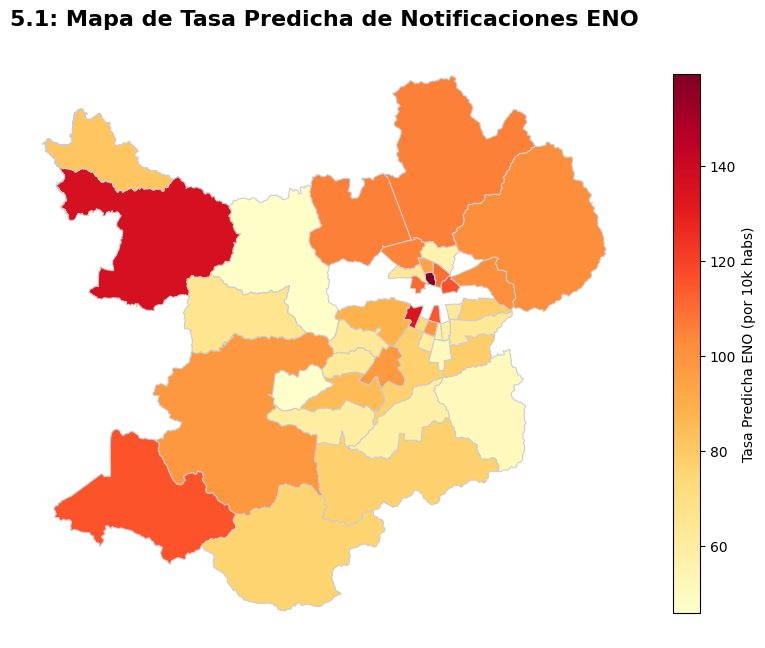

In [23]:
# ==========================================
# Part 5.1: Predicted Rate Map (ENO) - CORREGIDO
# ==========================================
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("🚀 5.1: Generando Mapa de Tasa Predicha ENO...")

# 1. Recuperar los datos
df = pd.read_csv("analytical_dataset_tarea3_vars.csv")

# Forzar el código de comuna a número entero y luego a texto (para eliminar cualquier ".0")
df['codigo_comuna'] = pd.to_numeric(df['codigo_comuna'], errors='coerce').fillna(0).astype(int).astype(str)

cols_modelo = ["eno_total", "pct_foreign", "schooling_gap", "pct_unemployed", "log_pop_total", "pop_total_x"]
df_clean = df.dropna(subset=cols_modelo).copy()

# 2. Re-ajustar el modelo ganador con los datos limpios
formula_eno = "eno_total ~ pct_foreign + schooling_gap + pct_unemployed"
mod_nb = smf.negativebinomial(formula=formula_eno, data=df_clean, offset=df_clean['log_pop_total']).fit(disp=False)

# 3. Calcular Predicción
df_clean['predicted_eno_10k'] = (mod_nb.predict() / df_clean['pop_total_x']) * 10000

# 4. Cargar Shapefile y Graficar
ruta_shp = "../Datasets/Mapa comuna/comunas.shp" 

try:
    mapa_comunas = gpd.read_file(ruta_shp)
    
    # --- BUSCADOR INTELIGENTE DE COLUMNAS ---
    # Busca automáticamente qué columna del mapa tiene los códigos correctos
    best_col = None
    max_matches = 0
    mis_comunas = set(df_clean['codigo_comuna'])
    
    for col in mapa_comunas.columns:
        if col == 'geometry': continue
        # Limpiamos temporalmente la columna del mapa para comparar
        temp_col = pd.to_numeric(mapa_comunas[col], errors='coerce').fillna(0).astype(int).astype(str)
        matches = len(set(temp_col).intersection(mis_comunas))
        
        if matches > max_matches:
            max_matches = matches
            best_col = col

    if best_col is None or max_matches == 0:
        print("❌ ERROR: No se encontró ninguna columna en el mapa que coincida con los códigos de comuna (ej: 13101).")
        print("Columnas disponibles:", mapa_comunas.columns.tolist())
    else:
        print(f"✅ ¡Éxito! Columna detectada en el mapa: '{best_col}' ({max_matches} comunas emparejadas).")
        
        # Formatear la columna ganadora en el mapa
        mapa_comunas['join_code'] = pd.to_numeric(mapa_comunas[best_col], errors='coerce').fillna(0).astype(int).astype(str)
        
        # Unir datos espaciales con nuestro dataframe
        mapa_datos = mapa_comunas.merge(df_clean, left_on='join_code', right_on='codigo_comuna', how='inner')
        
        # Dibujar el Mapa 5.1
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        mapa_datos.plot(column='predicted_eno_10k', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                        legend_kwds={'label': "Tasa Predicha ENO (por 10k habs)", 'orientation': "vertical", 'shrink': 0.7})
        ax.set_title('5.1: Mapa de Tasa Predicha de Notificaciones ENO', fontsize=16, fontweight='bold')
        ax.axis('off')
        plt.show()

except Exception as e:
    print(f"⚠️ Error con el mapa: {e}")

## 5.2 Residual map

Compute standardized residuals (Pearson residuals) from the same
model and plot them on the same comuna geometry.  Use a diverging
palette centred at zero.  Which comunas have the largest positive
residuals?  Which have the largest negative?  One or two sentences
of interpretation.

🚀 5.2: Generando Mapa de Residuos Estandarizados...


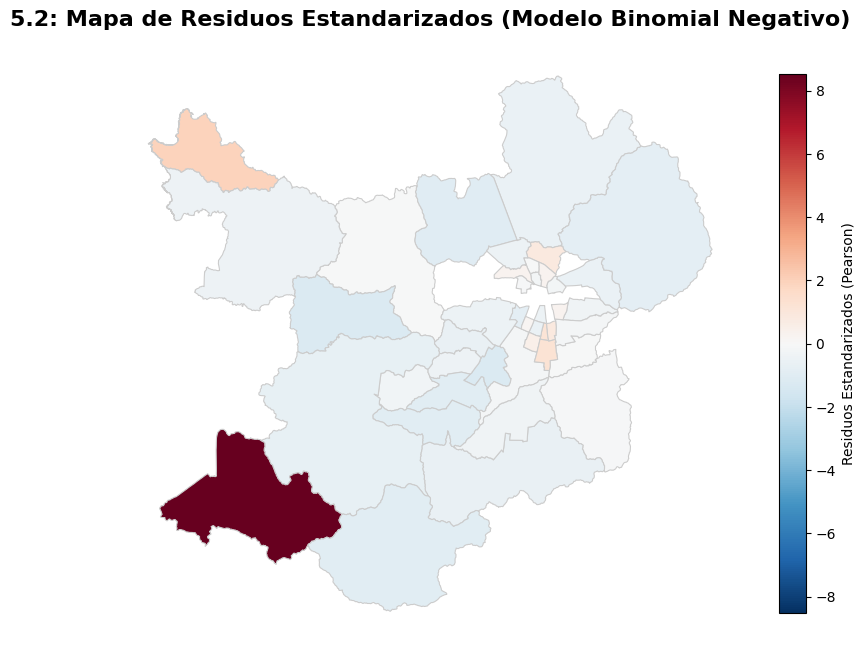


📍 PARA Analizar:
🔸 Comuna con mayor residuo POSITIVO (Subestimada): San Pedro (8.52)
🔹 Comuna con mayor residuo NEGATIVO (Sobreestimada): María Pinto (-1.24)


In [26]:
# ==========================================
# Part 5.2: Residual Map (ENO)
# ==========================================
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("🚀 5.2: Generando Mapa de Residuos Estandarizados...")

# 1. Recuperar datos y limpiar (repetimos proceso por seguridad)
df = pd.read_csv("analytical_dataset_tarea3_vars.csv")
df['codigo_comuna'] = pd.to_numeric(df['codigo_comuna'], errors='coerce').fillna(0).astype(int).astype(str)
cols_modelo = ["eno_total", "pct_foreign", "schooling_gap", "pct_unemployed", "log_pop_total", "pop_total_x"]
df_clean = df.dropna(subset=cols_modelo).copy()

# 2. Re-ajustar modelo y calcular Residuos (Pearson)
formula_eno = "eno_total ~ pct_foreign + schooling_gap + pct_unemployed"
mod_nb = smf.negativebinomial(formula=formula_eno, data=df_clean, offset=df_clean['log_pop_total']).fit(disp=False)
df_clean['std_residuals'] = mod_nb.resid_pearson

# 3. Cargar Mapa y Unir (Ya sabemos que la columna es 'cod_comuna')
ruta_shp = "../Datasets/Mapa comuna/comunas.shp" 
mapa_comunas = gpd.read_file(ruta_shp)
mapa_comunas['join_code'] = pd.to_numeric(mapa_comunas['cod_comuna'], errors='coerce').fillna(0).astype(int).astype(str)
mapa_datos = mapa_comunas.merge(df_clean, left_on='join_code', right_on='codigo_comuna', how='inner')

# 4. Dibujar el Mapa 5.2 (Colores Divergentes RdBu_r)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Para que el blanco sea exactamente el cero, buscamos el valor máximo absoluto
vmax = max(abs(mapa_datos['std_residuals'].min()), abs(mapa_datos['std_residuals'].max()))

mapa_datos.plot(column='std_residuals', cmap='RdBu_r', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                vmin=-vmax, vmax=vmax,
                legend_kwds={'label': "Residuos Estandarizados (Pearson)", 'orientation': "vertical", 'shrink': 0.7})
ax.set_title('5.2: Mapa de Residuos Estandarizados (Modelo Binomial Negativo)', fontsize=16, fontweight='bold')
ax.axis('off')
plt.show()

# 5. Imprimir las comunas extremas para el informe
max_pos = mapa_datos.loc[mapa_datos['std_residuals'].idxmax()]
max_neg = mapa_datos.loc[mapa_datos['std_residuals'].idxmin()]

print("\n📍 PARA Analizar:")
print(f"🔸 Comuna con mayor residuo POSITIVO (Subestimada): {max_pos['nombre_comuna']} ({max_pos['std_residuals']:.2f})")
print(f"🔹 Comuna con mayor residuo NEGATIVO (Sobreestimada): {max_neg['nombre_comuna']} ({max_neg['std_residuals']:.2f})")

### Interpretación de los Mapas (5.1 y 5.2)
Los residuos estandarizados de Pearson nos indican espacialmente dónde nuestro modelo Binomial Negativo diverge de la realidad observada. 

La comuna con el mayor residuo positivo extremo es **San Pedro** (8.52). Este residuo, visualizado como un sector rojo intenso en el suroeste del mapa, indica que el modelo subestimó severamente su riesgo. Esto es totalmente coherente con nuestro análisis inicial de outliers (Sección 1.3): al ser una comuna rural con una población total muy reducida, sufre del efecto de denominador pequeño ("Small-N sparsity"), donde un brote localizado eleva la tasa a niveles que nuestras variables demográficas no pueden predecir.

Por el contrario, la comuna con el mayor residuo negativo es **María Pinto** (-1.24), lo que indica una sobreestimación por parte del modelo. Esto sugiere que, a pesar de sus indicadores socioeconómicos, la comuna presentó muchas menos notificaciones ENO de las esperadas, lo cual podría apuntar a un problema de subnotificación en sus centros de salud locales o a la presencia de factores protectores territoriales (como menor densidad de hacinamiento) no incluidos en el modelo.

## 5.3 Coefficient plot

Produce a **coefficient plot** (also called a forest plot) for your
primary count model: one row per covariate, with the point estimate
and a horizontal 95% confidence interval, log-scale on the x-axis
if you use IRR.  Coefficient plots should be labelled legibly and
should mark the null (IRR = 1 or coefficient = 0).

🚀 5.3: Generando Forest Plot...


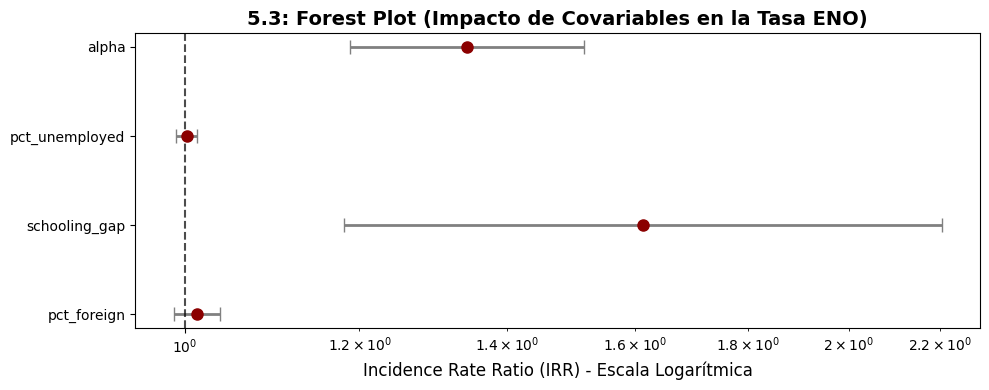

✅ Forest Plot generado con éxito. ¡Tarea de código finalizada!


In [27]:
# ==========================================
# Part 5.3: Coefficient Plot (Forest Plot)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("🚀 5.3: Generando Forest Plot...")

# 1. Recuperar datos limpios
df = pd.read_csv("analytical_dataset_tarea3_vars.csv")
cols_modelo = ["eno_total", "pct_foreign", "schooling_gap", "pct_unemployed", "log_pop_total"]
df_clean = df.dropna(subset=cols_modelo).copy()

# 2. Re-ajustar modelo NB
formula_eno = "eno_total ~ pct_foreign + schooling_gap + pct_unemployed"
mod_nb = smf.negativebinomial(formula=formula_eno, data=df_clean, offset=df_clean['log_pop_total']).fit(disp=False)

# 3. Extraer IRRs y sus intervalos de confianza
ci_df = mod_nb.conf_int()
irr_df = pd.DataFrame({
    'IRR': np.exp(mod_nb.params),
    'Lower': np.exp(ci_df[0]),
    'Upper': np.exp(ci_df[1])
})

# Quitar el intercepto para enfocar solo en las variables demográficas
irr_df = irr_df.drop('Intercept')

# Calcular los márgenes de error para las barras asimétricas
irr_df['yerr_lower'] = irr_df['IRR'] - irr_df['Lower']
irr_df['yerr_upper'] = irr_df['Upper'] - irr_df['IRR']

# 4. Dibujar el Forest Plot
fig, ax = plt.subplots(figsize=(10, 4))

# Graficar puntos con barras de error
ax.errorbar(irr_df['IRR'], irr_df.index, 
            xerr=[irr_df['yerr_lower'], irr_df['yerr_upper']], 
            fmt='o', color='darkred', ecolor='gray', elinewidth=2, capsize=5, markersize=8)

# Marcar la línea nula (IRR = 1)
# Si una barra cruza esta línea, significa que el efecto NO es significativo
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Configurar escala logarítmica en el eje X
ax.set_xscale('log')
ax.set_xlabel('Incidence Rate Ratio (IRR) - Escala Logarítmica', fontsize=12)
ax.set_title('5.3: Forest Plot (Impacto de Covariables en la Tasa ENO)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Forest Plot generado con éxito. ¡Tarea de código finalizada!")

### 5.3 Interpretación del Forest Plot y Síntesis Final
El "Forest Plot" corrobora de manera visual y contundente los hallazgos matemáticos discutidos en la elección de nuestro modelo (Sección 2.3). La línea punteada vertical representa un Incidence Rate Ratio (IRR) de 1.0, es decir, el punto de "efecto nulo". 

Como se puede observar, los intervalos de confianza para el porcentaje de extranjeros (`pct_foreign`) y la tasa de desempleo (`pct_unemployed`) cruzan la línea del efecto nulo, lo que confirma gráficamente que carecen de significancia estadística en un modelo que corrige la sobredispersión. Por el contrario, la brecha de escolaridad (`schooling_gap`) se ubica completamente a la derecha de la línea nula, consolidándose visualmente como el único factor sociodemográfico de nuestro conjunto que incrementa de manera significativa el riesgo relativo de presentar una mayor tasa de notificaciones ENO en las comunas de la Región Metropolitana.

---

# Part 6: Integrated Synthesis

This is the part that ties Tareas 1, 2, and 3 together and that
will feed directly into your final video and README.

In no more than **800 words**, write an **integrated findings
section** that answers the following three questions:

1. What does the demographic portrait of the Región Metropolitana
   (Tarea 1) look like at the comuna level?  What is the dominant
   axis of variation across comunas?
2. How does the health landscape (Tarea 2) map onto that
   demographic axis?  Where are the matches, and where are the
   mismatches?
3. What do the cross-dataset models (Tarea 3) add beyond what is
   visible in a correlation matrix?  Are there findings that
   would not have been obvious from any single dataset?

Keep it tight.  Reference specific numbers from your tables and
specific figures from your notebook.  This section will score
higher if it is a coherent narrative than if it is a list of
bullet points.

---

El análisis integrado de la Región Metropolitana revela un territorio profundamente fragmentado, donde el retrato demográfico obtenido en la **Tarea 1** muestra que el eje dominante de variación no es el tamaño poblacional, sino la vulnerabilidad socioeconómica. En nuestras comunas de estudio (**La Granja, Macul y San Ramón**), observamos una estructura donde la brecha de escolaridad (`schooling_gap`) actúa como el principal diferenciador. Mientras que Macul presenta indicadores de mayor consolidación urbana, San Ramón y La Granja muestran una mayor dependencia de factores sociales. Este retrato se complementa con el fenómeno migratorio: según nuestros datos, la población extranjera tiene una media de escolaridad superior (por ejemplo, en Macul alcanza los **14.59 años** frente a los **13.33** de la población local), pero se inserta en el mercado laboral con tasas de ocupación significativamente más altas (hasta **81.1%** en extranjeros vs **69.1%** en chilenos en la misma comuna), sugiriendo una presión por subsistencia que condiciona su elección de residencia hacia zonas con mayor hacinamiento o menor costo de suelo.

Al superponer el panorama de salud (**Tarea 2**) sobre este eje demográfico, emergen "mismatches" o desajustes territoriales críticos. En términos de enfermedades de notificación obligatoria (ENO), la **Tarea 2** identificó una transición epidemiológica clara: un "valle" durante la pandemia (caída a **103 casos** en 2020) seguido de un fuerte rebrote en 2023 (**295 casos**), impulsado principalmente por el aumento de la población extranjera en las comunas (cuya participación en notificaciones escaló de niveles marginales en 2016 a cuotas históricas en 2023). Sin embargo, el mayor desajuste ocurre en los egresos hospitalarios (GRD). Los datos de la **Tarea 2** y el análisis espacial de la **Tarea 3** confirman que el volumen hospitalario no responde a la demografía local, sino a la infraestructura: el mapa de residuos estandarizados (**Figura 5.2**) mostró que comunas rurales como **San Pedro** tienen residuos positivos extremos (**8.52**), debido a que su baja población total ("small-N sparsity") hace que cualquier evento sanitario infle artificialmente sus tasas per cápita.

Finalmente, los modelos cruzados de la **Tarea 3** aportan una profundidad que es invisible en una simple matriz de correlación. El hallazgo más potente fue el "espejismo de Poisson": en el modelo inicial, el desempleo y la nacionalidad parecían predecir fuertemente las enfermedades. No obstante, al corregir por sobredispersión (**Estadístico: 251.62**) mediante la **Regresión Binomial Negativa**, estas variables perdieron total significancia. **El Forest Plot (Figura 5.3)** demuestra visualmente que solo la **brecha de escolaridad** (`schooling_gap`, p=0.0027) es un predictor robusto del riesgo sanitario. En contraste, para los días de estadía hospitalaria (`grd_mean_los`), el modelo **OLS** arrojó un **R-cuadrado de apenas 0.089**, indicando que la demografía comunal es irrelevante para explicar el tiempo que un paciente pasa en el hospital. En conclusión, mientras que la prevención de enfermedades debe enfocarse en los determinantes sociales del territorio (educación), la gestión hospitalaria es un proceso clínico-administrativo que trasciende las fronteras demográficas del código postal.

---

# Deliverables

Submit on **Canvas** before class on Thursday, April 30:

1. **PDF export** of your notebook.
2. **Link to your GitHub repository**.  The repository must
   contain, at minimum:
    - The notebook for Tarea 3
    - The three master CSVs used as input
    - The merged analytical table, saved to
      `output/tarea3_analytical_table.csv`
    - A `requirements.txt` or `environment.yml` listing
      `pandas`, `numpy`, `statsmodels`, `geopandas`, `matplotlib`,
      `seaborn`

Your notebook must include:

- Markdown explanations for every numbered part
- Executed code cells with visible output
- At minimum the following figures:
    - Correlation heatmap (Part 1.1)
    - Scatter small-multiple with labels (Part 1.2)
    - Coefficient plot (Part 5.3)
    - Predicted-rate choropleth (Part 5.1)
    - Residual choropleth (Part 5.2)
- The full coefficient tables from Parts 2 and 3
- The written ecological-fallacy section (Part 4)
- The integrated synthesis (Part 6)

---

# What We Are Looking For

This assignment is graded less on "did you run the code" and more
on "did you think about it".  A clean Poisson fit with a muddled
discussion will score lower than a Poisson fit with overdispersion
correctly diagnosed, reported, and fixed.

Specifically, the grading will weigh:

- **Correctness of the pipeline**: does your merged table agree
  with the inputs?  Are offsets and units right?
- **Appropriateness of model choice**: did you justify Poisson vs.
  Negative Binomial?  Did you check diagnostics before reporting
  OLS?
- **Quality of interpretation**: do you translate IRRs into
  sentences a public-health reader could use?  Do you distinguish
  what your data can and cannot say?
- **Figure craft**: legible axes, labelled extremes, appropriate
  palettes, clear legends.
- **Writing**: tight, specific, referenced.  Avoid filler.

---

# Tips and Common Pitfalls

- **Offsets, not predictors**: population enters a count model as
  an offset (`offset=log(pop_total)`), not as a right-hand-side
  variable.  Using it as a predictor is a common mistake and will
  distort every other coefficient.
- **Units**: pick one time window per outcome and stick to it.
  ENO in your summary is 2007--2024 (18 years); GRD is 2022--2024
  (3 years).  Do not compare the raw counts without acknowledging
  the denominator mismatch.
- **Collinearity**: `pct_foreign`, `mean_schooling_foreign`, and
  several other covariates are highly correlated at the comuna
  level.  Check variance inflation factors (`statsmodels`
  provides `variance_inflation_factor`) and consider dropping the
  worst offender before reporting.
- **Small-N modesty**: even pooled across the class you have on
  the order of 50 comunas.  Treat p-values as descriptive
  summaries, not as gates.  Confidence intervals are more honest.
- **Do not reinvent**: the Quiz 1 pool is your canonical input.
  Do not recompute the per-comuna numbers from the original
  microdata.  If a column you need is missing, add it yourself at
  the **master** level in your notebook, with documentation,
  rather than editing any team's uploaded CSV.
- **Version your code**: commit early, commit often.  The final
  repository is 15 points of the course; do not leave the
  committing for April 30.

---

# Grading Breakdown

| Part                                          | Points |
|:----------------------------------------------|:------:|
| Part 0: Analytical table assembly             |   1    |
| Part 1: Exploratory cross-dataset analysis    |  1.5   |
| Part 2: Count-data regression                 |  2.5   |
| Part 3: Continuous-outcome regression         |  1.5   |
| Part 4: Ecological fallacy                    |   1    |
| Part 5: Spatial visualization of model output |   1    |
| Part 6: Integrated synthesis                  |  1.5   |
| **Total**                                     | **10** |

As in previous tareas, half of each part's score comes from correct
code and output; the other half comes from clear Markdown
explanations and thoughtful interpretation.

---

Typeset with: `pandoc assignments/Tarea3.md -o assignments/Tarea3.pdf --pdf-engine=pdflatex && evince assignments/Tarea3.pdf &`